# Численные методы поиска минимума — продолжение

Задачи берём из июньского списка: ответы к ним уже получены аналитически, значит любой новый метод есть с чем сверить.

Код пишем в пустых ячейках под условиями, ответы на вопросы — текстом в ячейках «Ответ».

## Функции из прошлых работ

Перенесены как есть, чтобы новые методы сравнивались со старыми в одном файле.

In [31]:
import math
import random

In [32]:
def golden_section(f, a, b, eps=1e-6, max_iter=100):
   
    phi = (1 + 5**0.5) / 2   # 1.618...
    k1 = 1 - 1 / phi          # 0.382
    k2 = 1 / phi              # 0.618

    # Первые две внутренние точки
    x1 = a + k1 * (b - a)
    x2 = a + k2 * (b - a)

    f1 = f(x1)
    f2 = f(x2)
    func_calls = 2  # счётчик вызовов функции

    for iteration in range(max_iter):
        current_len = b - a        

        if current_len < eps:
            break        

        if f1 < f2:
            # Минимум слева → [a, x2]
            b = x2
            x2 = x1  # старая x1 → новая x2
            f2 = f1
            x1 = a + k1 * (b - a) # считаем только одну новую точку
            f1 = f(x1)
            func_calls += 1
        else:
            # Минимум справа → [x1, b]
            a = x1
            x1 = x2                    # старая x2 → новая x1
            f1 = f2
            x2 = a + k2 * (b - a)
            f2 = f(x2)   # считаем только одну новую точку
            func_calls += 1

    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1
    return x_opt, f_opt, iteration + 1, func_calls

def bisection(f, a, b, eps=1e-6, max_iter=1000):

    f_a = f(a)
    f_b = f(b)
    func_calls = 2  # счётчик вызовов функции

    if f_a * f_b > 0:
        raise ValueError(
        f"на концах отрезка функция одного знака: "
        f"f({a}) = {f_a:.4g}, f({b}) = {f_b:.4g}; "
        f"деление пополам требует смены знака на [a; b]"
        )
    
    for iteration in range(max_iter):
        x = (a + b) / 2
        f_x = f(x)
        func_calls += 1

        if f_x == 0:
            return x, f_x, iteration + 1, func_calls
        
        if b - a < eps:
            return x, f_x, iteration + 1, func_calls
        
        if f_a * f_x < 0:
            b = x 
            f_b = f_x 
        else:
            a = x
            f_a = f_x

    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1

    return x_opt, f_opt, max_iter, func_calls


def make_func_along_x(f, y_fixed):
    def g(x):
        return f(x, y_fixed)             
    return g

def make_func_along_y(f, x_fixed):
    def h(y):
        return f(x_fixed, y) 
    return h

def coordinate_descent(f, bounds, eps=1e-3, max_iter=1000):
    
    # Вычисляем середину границ для каждой координаты
    x = (bounds[0][0] + bounds[0][1]) / 2
    y = (bounds[1][0] + bounds[1][1]) / 2

    converged = False 
    iteration_count = 0
    func_calls = 0  # счётчик вызовов f

    # Обёртка для подсчёта вызовов одномерной функции
    def counted_1d(g):
        def wrapper(x):
            nonlocal func_calls
            func_calls += 1
            return g(x)
        return wrapper

    for iteration in range(max_iter):
        x_old, y_old = x, y

        x_bounds, y_bounds = bounds[0], bounds[1]

        g_x = make_func_along_x(f, y) 
        x, _, _, _ = golden_section(counted_1d(g_x), x_bounds[0], x_bounds[1], eps)

        h_y = make_func_along_y(f, x)
        y, _, _, _ = golden_section(counted_1d(h_y), y_bounds[0], y_bounds[1], eps)

        iteration_count += 1

        if abs(x - x_old) < eps and abs(y - y_old) < eps:
            converged = True
            break  
            
    return x, y, converged, iteration_count, func_calls


Ниже перенеси остальные свои функции из ноутбука с одномерными задачами — прежде всего деление пополам для поиска минимума.

In [33]:
def bisection_minimize(f, a, b, eps=1e-6, max_iter=100):

    func_calls = 0  # счётчик вызовов функции
    
    for iteration in range (max_iter):
        #смотрим диаметр на отрезке a, b 
        # a - левее середины. b - правее середины
        current_len = b - a
        x_mid = (a + b) / 2
        delta = current_len * 0.01

        #считаем смещения
        d1 = x_mid - delta
        d2 = x_mid + delta
        
        if current_len < eps:
            break

        f_d1 = f(d1)
        f_d2 = f(d2)
        func_calls += 2
        
        if f_d1 > f_d2:      # справа ниже - минимум правее
            a = d1
        elif f_d1 < f_d2:    # слева ниже - минимум левее
            b = d2
        else:
            a = d1
            b = d2
    x_opt = (a + b) / 2
    f_opt = f(x_opt)
    func_calls += 1
    return x_opt, f_opt, iteration + 1, func_calls


In [34]:
# принимает на вход первую производную
def secant_method(f1, a, b, eps=1e-3, max_iter=100):
    x0, x1 = a, b

    f_x0 = f1(x0)
    f_x1 = f1(x1)

    func_calls = 2

    xi, f_xi = x1, f_x1

    for iteration in range(max_iter):

        # Защита от деления на ноль или почти ноль
        if abs(f_x1 - f_x0) < 1e-12:
            ok = abs(f_x1) <= eps and a < x1 < b
            return x1, f_x1, iteration + 1, func_calls, ok

        # Считаем новую точку
        xi = x1 - f_x1 * (x1 - x0) / (f_x1 - f_x0)
        f_xi = f1(xi)
        func_calls += 1

        # Критерий остановки по шагу. Сошлись только если в найденной
        # точке производная действительно близка к нулю: промежуточные
        # итерации секущей могут выходить за отрезок, это нормально.
        if abs(xi - x1) < eps:
            ok = abs(f_xi) <= eps and a < xi < b
            return xi, f_xi, iteration + 1, func_calls, ok

        # Обновляем точки: забываем самую старую
        x0 = x1
        f_x0 = f_x1

        x1 = xi
        f_x1 = f_xi

    return xi, f_xi, max_iter, func_calls, False


In [35]:
ZERO_EPS = 1e-12
def newton(f1, f2, x0, eps=1e-3, max_iter=100):
    
    func_calls = 0  # счётчик вызовов функции

    for iteration in range(max_iter):

        f1_x0 = f1(x0)
        f2_x0 = f2(x0) 
        func_calls += 2        

        if abs(f2_x0) < ZERO_EPS:                      
            return x0, f1_x0, iteration +1, func_calls, False
        else:   
            #вычисляем новую точку
            x1 = x0 - f1_x0 / f2_x0

        f1_x1 = f1(x1)
        func_calls += 1

        if abs(x1 - x0) < eps:
            return x1, f1_x1, iteration + 1, func_calls, True

        x0 = x1      
    return x0, f1_x0, iteration +1, func_calls, False


**Вывод:** В условии остановки мы проверяем длину последнего шага: abs(x1 - x0) < eps. Это не та величина, точность которой обещана в заголовке таблицы. В заголовке таблицы обещана точность по координате — расстояние от лучшей найденной точки до истинного минимума.

Поскольку шаг в методе Ньютона вычисляется как x1 = x0 - f1_x0 / f2_x0, малый шаг означает, что отношение f'/f'' мало. Вблизи минимума, где кривизна f'' не меняется сильно, это свидетельствует о том, что и производная f' близка к нулю, а значит, мы находимся вблизи минимума.

Раньше мы останавливались по условию |f'(x)| < eps, но малая производная не означала, что мы близко к минимуму по координате: на пологом участке |f′(x)| может быть меньше eps, а точка — ещё далеко от x_min (производная малая, но не нулевая). А при f′(x) ровно нулевом точка и есть экстремум — но остановка по |f′| < eps до такого случая как раз не доводит. Проверка длины шага |x_new - x_old| < eps учитывает кривизну функции через f'' и даёт более надёжную гарантию. Возле минимума, где f″ почти не меняется, шаг почти равен расстоянию от текущей точки до минимума: x − x* ≈ f′(x)/f″(x*). Вот почему остановка по шагу здесь честно означает точность по координате — а для метода с медленной сходимостью не означала бы.

**Проверка связки на числах.** Возьмём задачу 0 (дорога/лес): её минимум известен аналитически, x* = 8 − √(81/7) ≈ 4.5983. Прогоняем метод Ньютона и на каждой итерации печатаем длину шага |f′/f″| и настоящее расстояние |x − x*|. Если возле минимума эти числа идут рядом — связка «остановка по шагу ≈ точность по координате» подтверждена, а не просто заявлена.

In [36]:
def f_0(x):
    return x / 4.0 + math.sqrt((8.0 - x) ** 2 + 9.0) / 3.0

def d1_0(x):
    return (4 * x + 3 * math.sqrt((x - 8) ** 2 + 9) - 32) / (12 * math.sqrt((x - 8) ** 2 + 9))

def d2_0(x):
    return 3 / ((x - 8) ** 2 + 9) ** 1.5

x_star = 8 - math.sqrt(81 / 7)   # аналитический минимум задачи 0
eps = 1e-3

x = 3.0
print("итер |         x         |  шаг |f'/f''| |  |x - x*|  ")
print("-" * 68)
for it in range(1, 20):
    step = d1_0(x) / d2_0(x)     # ньютоновский шаг
    dist = abs(x - x_star)       # настоящее расстояние до минимума
    print(f"{it:>4} | {x:17.9f} | {abs(step):12.3e} | {dist:12.3e}")
    if abs(step) < eps:
        print("остановка по шагу: |f'/f''| < eps")
        break
    x = x - step

итер |         x         |  шаг |f'/f''| |  |x - x*|  
--------------------------------------------------------------------
   1 |       3.000000000 |    2.368e+00 |    1.598e+00
   2 |       5.367858520 |    6.391e-01 |    7.695e-01
   3 |       4.728755319 |    1.263e-01 |    1.304e-01
   4 |       4.602461817 |    4.138e-03 |    4.142e-03
   5 |       4.598323996 |    4.253e-06 |    4.253e-06
остановка по шагу: |f'/f''| < eps


In [37]:
def parabolic(f, a, b, eps=1e-6, max_iter=100):
    # находим третью точку
    c = (a + b) / 2  
    f_a, f_b, f_c = f(a), f(b), f(c)
    
    # проверяем, что функция в середине меньше, чем на концах
    if f_c > f_a or f_c > f_b:
        raise ValueError("середина отрезка не является самой низкой точкой")
    
    # x1=a, x2=c, x3=b
    x1, x2, x3 = a, c, b
    f1, f2, f3 = f_a, f_c, f_b
    func_calls = 3  # счётчик вызовов f

    #считаем вершину параболы  
    for iteration in range(max_iter):
      
        D1 = (f2 - f1) / (x2 - x1)
        D2 = (f3 - f2) / (x3 - x2)
        A = (D2 - D1) / (x3 - x1)

        if abs(A) < 1e-12:
            # возвращаем текущую лучшую точку
            return x2, f2, iteration + 1, False, func_calls
        
        # Вершина параболы 
        x_new = (x1 + x2) / 2 - D1 / (2 * A)
        f_new = f(x_new)
        func_calls += 1

        if abs(x_new - x2) < eps:
            return x_new, f_new, iteration + 1, True, func_calls

        points = [(x1, f1), (x2, f2), (x3, f3), (x_new, f_new)]
        points.sort(key=lambda p: p[0]) 

        worst = max(points, key=lambda point: point[1]) 
        points.remove(worst)

        x1, f1 = points[0]
        x2, f2 = points[1]
        x3, f3 = points[2]

    return x2, f2, max_iter, False, func_calls


In [38]:
def brent(f, a, b, eps=1e-3, max_iter=100):
    # a, b	границы текущего отрезка
    # x	лучшая точка (самое низкое f)
    # w	вторая по качеству точка
    # v	третья по качеству точка
    # u	новая точка-кандидат
    # d	шаг, сделанный в прошлый раз
    # e	шаг, сделанный перед d
    # c_gold = (3−√5)/2	константа золотого сечения ≈ 0.382

    c_gold = (3 - math.sqrt(5)) / 2 
    x = w = v = a + c_gold * (b - a)
    fx = fw = fv = f(x)
    d = 0
    e = 0
    func_calls = 1

    for iteration in range (max_iter):
        if (b - a) < eps:
            break

        u = None

        if e != 0 and v != w and w != x and v != x: #можно ли строить параболу?
            D1 = (fw - fx) / (w - x)
            D2 = (fv - fw) / (v - w)
            A = (D2 - D1) / (v - x)

            if abs(A) > 1e-12: # если парабола не вырождается в прямую, ищем вершину
                apex = (x + w) / 2 - D1 / (2 * A)
                if a < apex < b and abs(apex - x) < 0.5 * abs(e):
                    u = apex    #тогда вершина кандидат на новую лучшую точку

        if u is None: # если парабола не подошла или не получилась, пробуем золотое сечение
            if x < (a + b) / 2: #если в левой половине, шагаем вправо
                u = x + (b - x) * c_gold
            else: 
                u = x - (x - a) * c_gold

        e = d
        d = u - x   #величина текущего шага
        fu = f(u)
        func_calls += 1

        if fu <= fx:    #если новая точка лучше x
            if u >= x:
                a = x
            else:
                b = x
            v, fv = w, fw
            w, fw = x, fx
            x, fx = u, fu
        else:   #если хуже x
            if u >= x:
                b = u
            else:
                a = u
                
            #но если она улчше w или v
            if fu <= fw or w == x: 
                v, fv = w, fw
                w, fw = u, fu
            elif fu <= fv or v == x or v == w:
                v, fv = u, fu

    return x, fx, func_calls, iteration 
                                                

In [39]:
def gradient_descent(f, f1, f2, x0, eps=1e-3, max_iter=100):
    x = x0
    f_x = f(x)
    func_calls = 1
    history_x = [x]      
    history_f = [f_x] 
    
    for iteration in range(max_iter):
        grad = f1(x)
        hess = f2(x)
        
        if hess == 0:
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False

        step = grad / hess

        if not math.isfinite(step):
            return x, f_x, iteration + 1, func_calls, history_x, history_f, False

        x_new = x - step   #новая точка
        f_new = f(x_new)
        func_calls += 1

        # Проверка на расхождение
        t = 1.0
        while f_new > f_x:
            t *= 0.5
            if t < 1e-12:
               return x, f_x, iteration + 1, func_calls, history_x, history_f, False
            
            x_new = x - t * step
            f_new = f(x_new)
            func_calls += 1

        # Проверка сходимости 
        if abs(x_new - x) < eps:
            history_x.append(x_new)
            history_f.append(f_new)
            return x_new, f_new, iteration + 1, func_calls, history_x, history_f, True

        x = x_new
        f_x = f_new        
        history_x.append(x)
        history_f.append(f_x)
        
    return x, f_x, iteration + 1, func_calls, history_x, history_f, False

---

## 1. Проверка методов на устойчивость

Возьми три задачи из июньского списка, решённые численно.

Прогони на каждой все три метода: **золотое сечение**, **деление пополам для минимума**, **деление пополам для корня f′(x) = 0**. Каждый метод — на трёх разных отрезках, содержащих ответ: узком, среднем и заведомо широком, например [0; 100].

Ответ не должен зависеть от того, какой отрезок выбран: минимум у задачи один. Проверь, так ли это у всех трёх методов.

Заполни таблицу:

| Задача | Метод | Узкий отрезок | Средний | Широкий | Аналитический ответ |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | золотое сечение |  1385.64|  1385.64|  1385.64|  |
| 1 | пополам, минимум |  1385.64|  1385.64|  1385.64|  1385.64|
| 1 | пополам, корень f′ |  1385.64|  1385.64|  1385.64|  |
| 2 | золотое сечение |  0.71|  0.71|  0.71|  |
| 2 | пополам, минимум |  0.71|  0.71|  0.71|  0.71|
| 2 | пополам, корень f′ |  0.71|  0.71|  0.71|  |
| 3 | золотое сечение |0.84/1.68/0.84 |  0.84/1.68/0.84 |  0.84/1.68/0.84 |  |
| 3 | пополам, минимум |  0.84/1.68/0.84 |  0.84/1.68/0.85|  0.84/1.69/0.83 |  0.84/1.68/0.84|
| 3 | пополам, корень f′ |  0.84/1.68/0.84 |  0.84/1.68/0.83|  0.84/1.68/0.84 |  |

In [40]:
import math
def evaluation():
    #5.Магазин продаёт 4800 единиц товара в год. Каждая поставка обходится в 600 руб. независимо от объёма, а хранение единицы на складе — 3 руб./год.
#Какой размер одной партии минимизирует суммарные годовые затраты на заказы и хранение 
    def logistic(q):
        return 2880000 / q + 1.5 * q

    def root(q):
        return - (2880000 / q ** 2) + 1.5

    print("Задача номер 5.")
    print(f"Узкий отрезок [1200; 1400]")
    x_opt, f_opt, _, _ = golden_section(logistic, 1200, 1400, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection_minimize(logistic, 1200, 1400, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection(root, 1200, 1400, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    print()

    print(f"Средний отрезок [600; 2000]")
    x_opt, f_opt, _, _ = golden_section(logistic, 500, 2500, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection_minimize(logistic, 500, 2500, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection(root, 500, 2500, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ") 
    print()

    print(f"Широкий отрезок [100; 5000]")
    x_opt, f_opt, _, _ = golden_section(logistic, 100, 5000, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection_minimize(logistic, 100, 5000, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")  
    x_opt, f_opt, _, _ = bisection(root, 100, 5000, eps=1e-2, max_iter=100) 
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")
    print() 

    #7. Над центром круглого стола радиусом 1 м висит лампа. Освещённость точки на краю стола пропорциональна синусу угла падения света и обратно
    #пропорциональна квадрату расстояния до лампы. На какой высоте повесить лампу, чтобы край стола был освещён максимально

    def illumination(h):
        
        return - (h / (h ** 2 + 1) ** 1.5)

    def root(h):
    
        numerator = 2 * h**2 - 1
        denominator = (h**2 + 1)**2.5
        return numerator / denominator

    print("Задача номер 7.")
    print(f"Узкий отрезок [0.5; 0.8]")
    x_opt, f_opt, _, _ = golden_section(illumination, 0.5, 0.8, eps=1e-2, max_iter=100)
    print(f"Высота: {x_opt:.2f}")  
    x_opt, f_opt, _, _ = bisection_minimize(illumination, 0.5, 0.8, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}")   
    x_opt, f_opt, _, _ = bisection(root, 0.5, 0.8, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}")  
    print()

    print(f"Средний отрезок [0.2; 2.0]")
    x_opt, f_opt, _, _ = golden_section(illumination, 0.2, 2.0, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}")  
    x_opt, f_opt, _, _ = bisection_minimize(illumination, 0.2, 2.0, eps=1e-2, max_iter=100)
    print(f"Высота: {x_opt:.2f}") 
    x_opt, f_opt, _, _ = bisection(root, 0.2, 2.0, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}") 
    print()

    print(f"Широкий отрезок [0.0; 5.0]")
    x_opt, f_opt, _, _ = golden_section(illumination, 0.0, 5.0, eps=1e-2, max_iter=100)
    print(f"Высота: {x_opt:.2f}")  
    x_opt, f_opt, _, _ = bisection_minimize(illumination, 0.0, 5.0, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}")  
    x_opt, f_opt, _, _ = bisection(root, 0.0, 5.0, eps=1e-2, max_iter=100) 
    print(f"Высота: {x_opt:.2f}") 
    print()

    #10. Нормандское окно — прямоугольник, завершённый сверху полукругом.
    #Периметр рамы 6 м. Какие размеры дадут наибольшую площадь окна, то есть пропустят максимум света?

    def area(r):
        return - (6 * r - (2 + math.pi / 2) * r ** 2)

    def root(r):
        return (4 + math.pi) * r - 6

    print("Задача номер 10.")
    print(f"Узкий отрезок [0.5; 0.9]")
    x_opt, f_opt, _, _ = golden_section(area, 0.5, 0.9, eps=1e-2, max_iter=100)
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    x_opt, f_opt, _, _ = bisection_minimize(area, 0.5, 0.9, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ") 
    x_opt, f_opt, _, _ = bisection(root, 0.5, 0.9, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    print()

    print(f"Средний отрезок [0.2; 1.5]")
    x_opt, f_opt, _, _ = golden_section(area, 0.2, 1.5, eps=1e-2, max_iter=100)
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    x_opt, f_opt, _, _ = bisection_minimize(area, 0.2, 1.5, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    x_opt, f_opt, _, _ = bisection(root, 0.2, 1.5, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    print()

    print(f"Широкий отрезок [0.0; 3.0]")
    x_opt, f_opt, _, _ = golden_section(area, 0.0, 3.0, eps=1e-2, max_iter=100)
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")
    x_opt, f_opt, _, _ = bisection_minimize(area, 0.0, 3.0, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ") 
    x_opt, f_opt, _, _ = bisection(root, 0.0, 3.0, eps=1e-2, max_iter=100) 
    print(f"Радиус: {x_opt:.2f} | Ширина: {2 * x_opt:.2f} | Высота: {(6 - 2 * x_opt - math.pi * x_opt) / 2:.2f} ")


if __name__ == "__main__":
    evaluation()


Задача номер 5.
Узкий отрезок [1200; 1400]
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 

Средний отрезок [600; 2000]
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 

Широкий отрезок [100; 5000]
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 
Оптимальный размер партии: 1385.64 ед / раз. 

Задача номер 7.
Узкий отрезок [0.5; 0.8]
Высота: 0.71
Высота: 0.71
Высота: 0.71

Средний отрезок [0.2; 2.0]
Высота: 0.71
Высота: 0.71
Высота: 0.71

Широкий отрезок [0.0; 5.0]
Высота: 0.71
Высота: 0.71
Высота: 0.71

Задача номер 10.
Узкий отрезок [0.5; 0.9]
Радиус: 0.84 | Ширина: 1.68 | Высота: 0.84 
Радиус: 0.84 | Ширина: 1.68 | Высота: 0.84 
Радиус: 0.84 | Ширина: 1.68 | Высота: 0.84 

Средний отрезок [0.2; 1.5]
Радиус: 0.84 | Ширина: 1.68 | Высота: 0.84 
Радиус: 0.84 | Ширина: 

## Автоматическая генерация таблиц

Код ниже запускает все методы на всех 11 задачах и выводит одну таблицу сравнения.

Для обновления данных — перезапустите ячейку.


In [41]:
"""
Автоматическая генерация таблицы сравнения численных методов поиска минимума.
Вызов в ноутбуке: generate_table()
"""
import math
from IPython.display import Markdown, display

# ============================================================
# 1. ЗАДАЧИ (0–10)
#    max=True — задача на максимум, f(x) берётся по модулю
# ============================================================

TASKS = {
    0: {
        "desc": "Путь через дорогу и лес",
        "func":   lambda x: x / 4.0 + math.sqrt((8.0 - x) ** 2 + 9.0) / 3.0,
        "deriv1": lambda x: 1 / 4 - (8 - x) / (3 * math.sqrt((8 - x) ** 2 + 9)),
        "deriv2": lambda x: 3 / ((8 - x) ** 2 + 9) ** 1.5,
        "range":  (0.0, 8.0),
        "max":    False,
        "x0":     4.0,
    },
    1: {
        "desc": "Цилиндрическая банка 0.5 л",
        "func":   lambda r: 1000 / r + 2 * math.pi * r ** 2,
        "deriv1": lambda r: -1000 / r ** 2 + 4 * math.pi * r,
        "deriv2": lambda r: 2000 / r ** 3 + 4 * math.pi,
        "range":  (1.0, 20.0),
        "max":    False,
        "x0":     5.0,
    },
    2: {
        "desc": "Загон у реки (200 м сетки)",
        "func":   lambda x: -(200 * x - 2 * x ** 2),
        "deriv1": lambda x: -200 + 4 * x,
        "deriv2": lambda x: 4.0,
        "range":  (0.0, 80.0),
        "max":    True,
        "x0":     25.0,
    },
    3: {
        "desc": "Коробка из листа 30x30",
        "func":   lambda h: -(900 * h - 120 * h ** 2 + 4 * h ** 3),
        "deriv1": lambda h: -900 + 240 * h - 12 * h ** 2,
        "deriv2": lambda h: 240 - 24 * h,
        "range":  (0.0, 7.0),
        "max":    True,
        "x0":     3.0,
    },
    4: {
        "desc": "Цена кофе (макс. выручка)",
        "func":   lambda a: -(150 + 10 * a) * (100 - 5 * a),
        "deriv1": lambda a: -250 + 100 * a,
        "deriv2": lambda a: 100.0,
        "range":  (0.0, 3.5),
        "max":    True,
        "x0":     2.0,
    },
    5: {
        "desc": "EOQ: размер партии товара",
        "func":   lambda q: 2880000 / q + 1.5 * q,
        "deriv1": lambda q: -2880000 / q ** 2 + 1.5,
        "deriv2": lambda q: 5760000 / q ** 3,
        "range":  (1000.0, 2000.0),
        "max":    False,
        "x0":     1500.0,
    },
    6: {
        "desc": "Балка из бревна d 30 см",
        "func":   lambda a: -math.sqrt(900 - a ** 2) * a ** 2,
        "deriv1": lambda a: 3 * a * (a ** 2 - 600) / math.sqrt(900 - a ** 2),
        "deriv2": lambda a: 6 * math.sqrt(900 - a ** 2) * (-a ** 4 + 1350 * a ** 2 - 270000) / (a ** 4 - 1800 * a ** 2 + 810000),
        "range":  (20.0, 28.0),
        "max":    True,
        "x0":     24.5,
    },
    7: {
        "desc": "Лампа над круглым столом",
        "func":   lambda h: -h / (h ** 2 + 1) ** 1.5,
        "deriv1": lambda h: (2 * h ** 2 - 1) / (h ** 2 + 1) ** 2.5,
        "deriv2": lambda h: -3 * h * (2 * h ** 2 - 3) / (h ** 2 + 1) ** 3.5,
        "range":  (0.0, 1.0),
        "max":    True,
        "x0":     0.5,
    },
    8: {
        "desc": "Жёлоб из полосы 30 см",
        "func":   lambda t: -225 * math.sin(t) / (2 - math.cos(t)),
        "deriv1": lambda t: 225 * (1 - 2 * math.cos(t)) / (math.cos(t) - 2) ** 2,
        "deriv2": lambda t: -450 * (math.cos(t) + 1) * math.sin(t) / (math.cos(t) - 2) ** 3,
        "range":  (0.0, math.pi / 2),
        "max":    True,
        "x0":     1.0,
    },
    9: {
        "desc": "Кровеносный сосуд (Пуазейль)",
        "func":   lambda t: (16 - math.cos(t)) / math.sin(t),
        "deriv1": lambda t: (1 - 16 * math.cos(t)) / math.sin(t) ** 2,
        "deriv2": lambda t: (-16 * math.sin(t) ** 2 - 2 * math.cos(t) + 32) / math.sin(t) ** 3,
        "range":  (0.1, 2.0),
        "max":    False,
        "x0":     1.5,
    },
    10: {
        "desc": "Нормандское окно (P=6 м)",
        "func":   lambda r: -(6 * r - (2 + math.pi / 2) * r ** 2),
        "deriv1": lambda r: (4 + math.pi) * r - 6,
        "deriv2": lambda r: 4 + math.pi,
        "range":  (0.1, 1.1),
        "max":    True,
        "x0":     0.5,
    },
}

EPS = 1e-3

# Точные аналитические ответы (для сверки численных методов)
ANALYTIC = {
    0:  8 - math.sqrt(81 / 7),        # путь через дорогу и лес
    1:  (250 / math.pi) ** (1 / 3),   # банка
    2:  50.0,                         # загон (ширина)
    3:  5.0,                          # коробка (высота)
    4:  2.5,                          # кофе (наценка a)
    5:  800 * math.sqrt(3),           # партия поставки
    6:  10 * math.sqrt(6),            # балка (сторона a)
    7:  1 / math.sqrt(2),             # лампа (высота)
    8:  math.pi / 3,                  # жёлоб (угол)
    9:  math.acos(1 / 16),            # сосуд (угол)
    10: 6 / (4 + math.pi),            # окно (радиус)
}

# ============================================================
# 3. Обёртки методов
#    Возвращают словарь {"iters", "fc", "fc1", "fc2", "x", "f_val"}
#    fc  — вызовы f(x)
#    fc1 — вызовы f'(x)
#    fc2 — вызовы f''(x)
# ============================================================

def _has(name):
    return name in globals()

def _dash():
    return {"iters": "-", "fc": "-", "fc1": "-", "fc2": "-", "x": None, "f_val": None}


def _fmt_pair(x, f_val):
    return f"{x:.3f}", f"{f_val:.3f}"


# --- Нулевой порядок ---

def wrap_golden(f, a, b, tid=None):
    if not _has("golden_section"):
        return _dash()
    try:
        x, f_val, it, fc = golden_section(f, a, b, eps=EPS, max_iter=100)
        return {"iters": it, "fc": fc, "fc1": "-", "fc2": "-", "x": x, "f_val": f_val}
    except Exception:
        return _dash()


def wrap_parabolic(f, a, b, tid=None):
    if not _has("parabolic"):
        return _dash()
    try:
        x, f_val, it, ok, fc = parabolic(f, a, b, eps=EPS, max_iter=100)
        if not ok:
            return _dash()
        return {"iters": it, "fc": fc, "fc1": "-", "fc2": "-", "x": x, "f_val": f_val}
    except Exception:
        return _dash()

def wrap_brent(f, a, b, tid=None):
    if not _has("brent"):
        return _dash()
    try:
        x, f_val, fc, it = brent(f, a, b, eps=EPS, max_iter=100)
        return {"iters": it, "fc": fc, "fc1": "-", "fc2": "-", "x": x, "f_val": f_val}
    except Exception:
        return _dash()


# --- Первый порядок (f') ---

def wrap_bisection_root(d, a, b, tid=None):
    # d = f'(x), для f_val нужен вызов f(x)
    if not _has("bisection"):
        return _dash()
    try:
        x, _, it, fc1 = bisection(d, a, b, eps=EPS, max_iter=100)
        task = TASKS.get(tid, {})
        f_val = abs(task["func"](x)) if task.get("max") else task["func"](x) if task else 0
        return {"iters": it, "fc": 1, "fc1": fc1, "fc2": "-", "x": x, "f_val": f_val}
    except Exception:
        return _dash()


def wrap_chord(d, a, b, tid=None):
    # d = f'(x), для f_val нужен вызов f(x)
    if not _has("secant_method"):
        return _dash()
    try:
        x, f_x, it, fc1, ok = secant_method(d, a, b, eps=EPS, max_iter=100)
        if not ok:
            return _dash()
        task = TASKS.get(tid, {})
        f_val = abs(task["func"](x)) if task.get("max") else task["func"](x) if task else 0
        return {"iters": it, "fc": 1, "fc1": fc1, "fc2": "-", "x": x, "f_val": f_val}
    except Exception:
        return _dash()


# --- Второй порядок (f' + f'') ---

def wrap_newton(d1, a, b, tid=None):
    if not _has("newton"):
        return _dash()
    task = TASKS.get(tid, {})
    d2 = task.get("deriv2")
    x0 = task.get("x0")
    if d2 is None or x0 is None:
        return _dash()

    # Считаем вызовы f' и f'' раздельно — оборачиваем производные в счётчики
    cnt = [0, 0]  # [f' calls, f'' calls]
    def _f1(x):
        cnt[0] += 1
        return d1(x)
    def _f2(x):
        cnt[1] += 1
        return d2(x)

    try:
        x, _, it, _, success = newton(_f1, _f2, x0, eps=EPS, max_iter=100)
        if not success:
            return _dash()
        f_val = abs(task["func"](x)) if task.get("max") else task["func"](x) if task else 0
        return {"iters": it, "fc": "-", "fc1": cnt[0], "fc2": cnt[1], "x": x, "f_val": f_val}
    except Exception:
        return _dash()


# ============================================================
# 4. Генерация таблицы
# ============================================================

def wrap_gradient_descent(f, a, b, tid=None):
    if not _has("gradient_descent"):
        return _dash()
    task = TASKS.get(tid, {})
    f1 = task.get("deriv1")
    f2 = task.get("deriv2")
    x0 = task.get("x0")
    if f1 is None or f2 is None or x0 is None:
        return _dash()
    try:
        x, f_val, it, fc, _, _, ok = gradient_descent(task["func"], f1, f2, x0, eps=EPS, max_iter=1000)
        if not ok:
            return _dash()
        # вызовы раздельно: f — старт + по одному на итерацию, f' и f'' — по одному на итерацию
        return {"iters": it, "fc": fc, "fc1": it, "fc2": it, "x": x, "f_val": f_val}
    except Exception:
        return _dash()

METHODS = [
    ("Золотое сечение",   wrap_golden,        "func"),
    ("Метод парабол",     wrap_parabolic,      "func"),
    ("Метод Брента",      wrap_brent,        "func"),
    ("Бисекция (f'=0)",   wrap_bisection_root, "deriv1"),
    ("Метод хорд",        wrap_chord,          "deriv1"),
    ("Метод Ньютона",     wrap_newton,         "deriv1"),
    ("Градиентный спуск", wrap_gradient_descent, "func"),
]

def generate_table():
    lines = []
    lines.append("# Сравнение численных методов поиска минимума")
    lines.append("")
    lines.append(f"Точность eps = {EPS}")
    lines.append("")

    header = ("| Задача | Суть | Метод | Ит. "
              "| f | f' | f'' "
              "| Диапазон | Аналит. | x | f(x) | f'(x) |")
    sep    = ("|:---:|:---|:---|:---:"
              "|:---:|:---:|:---:"
              "|:---|:---:|:---:|:---:|:---:|")
    lines.append(header)
    lines.append(sep)

    for tid in range(0, 11):
        task    = TASKS[tid]
        desc    = task["desc"]
        a, b    = task["range"]
        is_max  = task["max"]
        x0_val  = task.get("x0")

        a_val = ANALYTIC.get(tid)
        a_str = f"{a_val:.4f}" if a_val is not None else "-"

        # Формат диапазона (общий)
        if isinstance(a, float) and a == int(a) and isinstance(b, float) and b == int(b):
            rangestr = f"[{int(a)}; {int(b)}]"
        elif isinstance(a, int) and isinstance(b, int):
            rangestr = f"[{a}; {b}]"
        else:
            rangestr = f"[{a:.1f}; {b:.1f}]"

        nmethods = len(METHODS)
        for mi, (mname, mwrap, target_type) in enumerate(METHODS):
            target = task[target_type] if target_type in task else task["func"]
            if target is None:
                r = _dash()
            else:
                r = mwrap(target, a, b, tid)

            # Для Ньютона и градиентного спуска показываем x0 вместо интервала [a; b]
            if "Градиент" in mname:
                if isinstance(x0_val, (int, float)):
                    range_display = f"x0={x0_val:.1f}"
                else:
                    range_display = "-"
            elif "Ньютона" in mname:
                if isinstance(x0_val, float) and x0_val == int(x0_val):
                    range_display = f"x0={int(x0_val)}"
                elif isinstance(x0_val, (int, float)):
                    range_display = f"x0={x0_val:.1f}"
                else:
                    range_display = "-"
            else:
                range_display = rangestr

            # Форматируем x
            x_raw = r["x"]
            if isinstance(x_raw, (int, float)):
                x_str = f"{x_raw:.3f}"
            else:
                x_str = "-"

            # Форматируем f(x) с учётом модуля для максимизации
            f_raw = r["f_val"]
            if isinstance(f_raw, (int, float)):
                f_str = f"{abs(f_raw):.3f}" if is_max else f"{f_raw:.3f}"
            else:
                f_str = "-"

            # Проверка ответа: производная в найденной точке должна быть близка к нулю
            d1 = task.get("deriv1")
            f1_str = "-"
            if isinstance(x_raw, (int, float)) and d1 is not None:
                try:
                    f1_str = f"{d1(x_raw):.3f}"
                except Exception:
                    f1_str = "-"

            task_str = f"**{tid}**" if mi == 0 else ""
            desc_str = desc if mi == 0 else ""

            lines.append(f"| {task_str} | {desc_str} | {mname} "
                         f"| {r['iters']} "
                         f"| {r['fc']} | {r['fc1']} | {r['fc2']} "
                         f"| {range_display} | {a_str} "
                         f"| {x_str} | {f_str} | {f1_str} |")

    lines.append("")
    lines.append("---")
    lines.append("*Таблица сгенерирована автоматически. Для обновления — перезапустите ячейку.*")
    lines.append("*Для задач на максимум (2–4, 6–8, 10) f(x) = |значение|.*")
    lines.append("*Остановка: по длине отрезка — золотое сечение, Брент, бисекция; по длине шага — параболы, хорд, Ньютон, град. спуск 1D; по норме градиента — град. спуск 2D.*")

    display(Markdown("\n".join(lines)))


# ============================================================
# 5. ЗАПУСК
#    В ноутбуке: generate_table()
# ============================================================


In [42]:
generate_table()


# Сравнение численных методов поиска минимума

Точность eps = 0.001

| Задача | Суть | Метод | Ит. | f | f' | f'' | Диапазон | Аналит. | x | f(x) | f'(x) |
|:---:|:---|:---|:---:|:---:|:---:|:---:|:---|:---:|:---:|:---:|:---:|
| **0** | Путь через дорогу и лес | Золотое сечение | 20 | 22 | - | - | [0; 8] | 4.5983 | 4.598 | 2.661 | -0.000 |
|  |  | Метод парабол | 7 | 10 | - | - | [0; 8] | 4.5983 | 4.598 | 2.661 | -0.000 |
|  |  | Метод Брента | 9 | 10 | - | - | [0; 8] | 4.5983 | 4.598 | 2.661 | 0.000 |
|  |  | Бисекция (f'=0) | 14 | 1 | 16 | - | [0; 8] | 4.5983 | 4.598 | 2.661 | -0.000 |
|  |  | Метод хорд | 9 | 1 | 11 | - | [0; 8] | 4.5983 | 4.598 | 2.661 | 0.000 |
|  |  | Метод Ньютона | 4 | - | 8 | 4 | x0=4 | 4.5983 | 4.598 | 2.661 | 0.000 |
|  |  | Градиентный спуск | 4 | 5 | 4 | 4 | x0=4.0 | 4.5983 | 4.598 | 2.661 | 0.000 |
| **1** | Цилиндрическая банка 0.5 л | Золотое сечение | 22 | 24 | - | - | [1; 20] | 4.3013 | 4.301 | 348.734 | 0.008 |
|  |  | Метод парабол | 9 | 12 | - | - | [1; 20] | 4.3013 | 4.301 | 348.734 | 0.000 |
|  |  | Метод Брента | 9 | 10 | - | - | [1; 20] | 4.3013 | 4.301 | 348.734 | 0.000 |
|  |  | Бисекция (f'=0) | 16 | 1 | 18 | - | [1; 20] | 4.3013 | 4.301 | 348.734 | 0.001 |
|  |  | Метод хорд | 16 | 1 | 18 | - | [1; 20] | 4.3013 | 4.301 | 348.734 | 0.000 |
|  |  | Метод Ньютона | 4 | - | 8 | 4 | x0=5 | 4.3013 | 4.301 | 348.734 | -0.000 |
|  |  | Градиентный спуск | 4 | 5 | 4 | 4 | x0=5.0 | 4.3013 | 4.301 | 348.734 | -0.000 |
| **2** | Загон у реки (200 м сетки) | Золотое сечение | 25 | 27 | - | - | [0; 80] | 50.0000 | 50.000 | 5000.000 | -0.000 |
|  |  | Метод парабол | 2 | 5 | - | - | [0; 80] | 50.0000 | 50.000 | 5000.000 | 0.000 |
|  |  | Метод Брента | 5 | 6 | - | - | [0; 80] | 50.0000 | 50.000 | 5000.000 | -0.000 |
|  |  | Бисекция (f'=0) | 3 | 1 | 5 | - | [0; 80] | 50.0000 | 50.000 | 5000.000 | 0.000 |
|  |  | Метод хорд | 2 | 1 | 4 | - | [0; 80] | 50.0000 | 50.000 | 5000.000 | 0.000 |
|  |  | Метод Ньютона | 2 | - | 4 | 2 | x0=25 | 50.0000 | 50.000 | 5000.000 | 0.000 |
|  |  | Градиентный спуск | 2 | 3 | 2 | 2 | x0=25.0 | 50.0000 | 50.000 | 5000.000 | 0.000 |
| **3** | Коробка из листа 30x30 | Золотое сечение | 20 | 22 | - | - | [0; 7] | 5.0000 | 5.000 | 2000.000 | 0.008 |
|  |  | Метод парабол | 6 | 9 | - | - | [0; 7] | 5.0000 | 5.000 | 2000.000 | 0.000 |
|  |  | Метод Брента | 8 | 9 | - | - | [0; 7] | 5.0000 | 5.000 | 2000.000 | 0.000 |
|  |  | Бисекция (f'=0) | 14 | 1 | 16 | - | [0; 7] | 5.0000 | 5.000 | 2000.000 | 0.007 |
|  |  | Метод хорд | 5 | 1 | 7 | - | [0; 7] | 5.0000 | 5.000 | 2000.000 | -0.000 |
|  |  | Метод Ньютона | 4 | - | 8 | 4 | x0=3 | 5.0000 | 5.000 | 2000.000 | -0.000 |
|  |  | Градиентный спуск | 4 | 5 | 4 | 4 | x0=3.0 | 5.0000 | 5.000 | 2000.000 | -0.000 |
| **4** | Цена кофе (макс. выручка) | Золотое сечение | 18 | 20 | - | - | [0.0; 3.5] | 2.5000 | 2.500 | 15312.500 | -0.004 |
|  |  | Метод парабол | 2 | 5 | - | - | [0.0; 3.5] | 2.5000 | 2.500 | 15312.500 | 0.000 |
|  |  | Метод Брента | 5 | 6 | - | - | [0.0; 3.5] | 2.5000 | 2.500 | 15312.500 | 0.000 |
|  |  | Бисекция (f'=0) | 13 | 1 | 15 | - | [0.0; 3.5] | 2.5000 | 2.500 | 15312.500 | -0.018 |
|  |  | Метод хорд | 2 | 1 | 4 | - | [0.0; 3.5] | 2.5000 | 2.500 | 15312.500 | 0.000 |
|  |  | Метод Ньютона | 2 | - | 4 | 2 | x0=2 | 2.5000 | 2.500 | 15312.500 | 0.000 |
|  |  | Градиентный спуск | 2 | 3 | 2 | 2 | x0=2.0 | 2.5000 | 2.500 | 15312.500 | 0.000 |
| **5** | EOQ: размер партии товара | Золотое сечение | 30 | 32 | - | - | [1000; 2000] | 1385.6406 | 1385.641 | 4156.922 | 0.000 |
|  |  | Метод парабол | 7 | 10 | - | - | [1000; 2000] | 1385.6406 | 1385.641 | 4156.922 | 0.000 |
|  |  | Метод Брента | 8 | 9 | - | - | [1000; 2000] | 1385.6406 | 1385.641 | 4156.922 | -0.000 |
|  |  | Бисекция (f'=0) | 21 | 1 | 23 | - | [1000; 2000] | 1385.6406 | 1385.641 | 4156.922 | -0.000 |
|  |  | Метод хорд | 8 | 1 | 10 | - | [1000; 2000] | 1385.6406 | 1385.641 | 4156.922 | -0.000 |
|  |  | Метод Ньютона | 4 | - | 8 | 4 | x0=1500 | 1385.6406 | 1385.641 | 4156.922 | -0.000 |
|  |  | Градиентный спуск | 4 | 5 | 4 | 4 | x0=1500.0 | 1385.6406 | 1385.641 | 4156.922 | -0.000 |
| **6** | Балка из бревна d 30 см | Золотое сечение | 20 | 22 | - | - | [20; 28] | 24.4949 | 24.495 | 10392.305 | 0.005 |
|  |  | Метод парабол | 7 | 10 | - | - | [20; 28] | 24.4949 | 24.495 | 10392.305 | 0.000 |
|  |  | Метод Брента | 9 | 10 | - | - | [20; 28] | 24.4949 | 24.495 | 10392.305 | 0.000 |
|  |  | Бисекция (f'=0) | 14 | 1 | 16 | - | [20; 28] | 24.4949 | 24.495 | 10392.305 | -0.056 |
|  |  | Метод хорд | 7 | 1 | 9 | - | [20; 28] | 24.4949 | 24.495 | 10392.305 | -0.000 |
|  |  | Метод Ньютона | 2 | - | 4 | 2 | x0=24.5 | 24.4949 | 24.495 | 10392.305 | 0.000 |
|  |  | Градиентный спуск | 2 | 3 | 2 | 2 | x0=24.5 | 24.4949 | 24.495 | 10392.305 | 0.000 |
| **7** | Лампа над круглым столом | Золотое сечение | 16 | 18 | - | - | [0; 1] | 0.7071 | 0.707 | 0.385 | -0.000 |
|  |  | Метод парабол | 6 | 9 | - | - | [0; 1] | 0.7071 | 0.707 | 0.385 | 0.000 |
|  |  | Метод Брента | 7 | 8 | - | - | [0; 1] | 0.7071 | 0.707 | 0.385 | -0.000 |
|  |  | Бисекция (f'=0) | 11 | 1 | 13 | - | [0; 1] | 0.7071 | 0.708 | 0.385 | 0.000 |
|  |  | Метод хорд | 6 | 1 | 8 | - | [0; 1] | 0.7071 | 0.707 | 0.385 | 0.000 |
|  |  | Метод Ньютона | 4 | - | 8 | 4 | x0=0.5 | 0.7071 | 0.707 | 0.385 | -0.000 |
|  |  | Градиентный спуск | 4 | 5 | 4 | 4 | x0=0.5 | 0.7071 | 0.707 | 0.385 | -0.000 |
| **8** | Жёлоб из полосы 30 см | Золотое сечение | 17 | 19 | - | - | [0.0; 1.6] | 1.0472 | 1.047 | 129.904 | -0.021 |
|  |  | Метод парабол | 6 | 9 | - | - | [0.0; 1.6] | 1.0472 | 1.047 | 129.904 | 0.000 |
|  |  | Метод Брента | 7 | 8 | - | - | [0.0; 1.6] | 1.0472 | 1.047 | 129.904 | -0.000 |
|  |  | Бисекция (f'=0) | 12 | 1 | 14 | - | [0.0; 1.6] | 1.0472 | 1.047 | 129.904 | 0.022 |
|  |  | Метод хорд | 6 | 1 | 8 | - | [0.0; 1.6] | 1.0472 | 1.047 | 129.904 | 0.000 |
|  |  | Метод Ньютона | 3 | - | 6 | 3 | x0=1 | 1.0472 | 1.047 | 129.904 | -0.000 |
|  |  | Градиентный спуск | 3 | 4 | 3 | 3 | x0=1.0 | 1.0472 | 1.047 | 129.904 | -0.000 |
| **9** | Кровеносный сосуд (Пуазейль) | Золотое сечение | 17 | 19 | - | - | [0.1; 2.0] | 1.5083 | 1.508 | 15.969 | 0.001 |
|  |  | Метод парабол | 6 | 9 | - | - | [0.1; 2.0] | 1.5083 | 1.508 | 15.969 | 0.000 |
|  |  | Метод Брента | 8 | 9 | - | - | [0.1; 2.0] | 1.5083 | 1.508 | 15.969 | -0.000 |
|  |  | Бисекция (f'=0) | 12 | 1 | 14 | - | [0.1; 2.0] | 1.5083 | 1.508 | 15.969 | -0.007 |
|  |  | Метод хорд | 5 | 1 | 7 | - | [0.1; 2.0] | 1.5083 | 1.508 | 15.969 | -0.000 |
|  |  | Метод Ньютона | 2 | - | 4 | 2 | x0=1.5 | 1.5083 | 1.508 | 15.969 | -0.000 |
|  |  | Градиентный спуск | 2 | 3 | 2 | 2 | x0=1.5 | 1.5083 | 1.508 | 15.969 | -0.000 |
| **10** | Нормандское окно (P=6 м) | Золотое сечение | 16 | 18 | - | - | [0.1; 1.1] | 0.8401 | 0.840 | 2.520 | 0.002 |
|  |  | Метод парабол | 2 | 5 | - | - | [0.1; 1.1] | 0.8401 | 0.840 | 2.520 | 0.000 |
|  |  | Метод Брента | 10 | 11 | - | - | [0.1; 1.1] | 0.8401 | 0.840 | 2.520 | -0.000 |
|  |  | Бисекция (f'=0) | 11 | 1 | 13 | - | [0.1; 1.1] | 0.8401 | 0.840 | 2.520 | -0.003 |
|  |  | Метод хорд | 2 | 1 | 4 | - | [0.1; 1.1] | 0.8401 | 0.840 | 2.520 | 0.000 |
|  |  | Метод Ньютона | 2 | - | 4 | 2 | x0=0.5 | 0.8401 | 0.840 | 2.520 | 0.000 |
|  |  | Градиентный спуск | 2 | 3 | 2 | 2 | x0=0.5 | 0.8401 | 0.840 | 2.520 | 0.000 |

---
*Таблица сгенерирована автоматически. Для обновления — перезапустите ячейку.*
*Для задач на максимум (2–4, 6–8, 10) f(x) = |значение|.*
*Остановка: по длине отрезка — золотое сечение, Брент, бисекция; по длине шага — параболы, хорд, Ньютон, град. спуск 1D; по норме градиента — град. спуск 2D.*

| Метод | Условие остановки | Физический смысл | Гарантирует точность по координате? |
|---|---|---|---|
| `golden_section` | `b - a < eps` | Длина отрезка | Да |
| `bisection` | `b - a < eps` | Длина отрезка | Да |
| `brent` | `b - a < eps` | Длина отрезка | Да |
| `secant_method` | `abs(xi - x1) < eps` | Длина шага | Нет |
| `newton` | `abs(x1 - x0) < eps` | Длина шага | Да(вблизи минимума) |
| `parabolic` | `abs(x_new - x2) < eps` | Длина шага | Нет |
| `gradient_descent` | `abs(x_new - x) < eps` | Длина шага | Нет (только при a ≈ 1/f″) |
| `gradient_descent_plain` | `abs(x_new - x) < eps` | Длина шага | Да |
| `gradient_descent_backtrack` | `abs(x_new - x) < eps` | Длина шага | Да |
| `gradient_descent_2d_analit` | `grad_norm < eps` | Норма градиента | Нет |
| `gradient_descent_2d_numer` | `grad_norm < eps` | Норма градиента | Нет |



In [43]:
import math

answers = [
    8 - math.sqrt(81/7),             # 0
    (250/math.pi)**(1/3),            # 1
    (50, 100),                       # 2
    5,                               # 3
    2.5,                             # 4
    800*math.sqrt(3),                     # 5
    (10*math.sqrt(3), 10*math.sqrt(6)),   # 6
    1/math.sqrt(2),                 # 7
    (math.pi/3, 10),               # 8
    math.acos(1/16),                # 9
    (12/(4+math.pi), 6/(4+math.pi)),     # 10
]

print(answers)

[4.598319742916955, 4.3012700691404975, (50, 100), 5, 2.5, 1385.6406460551018, (17.32050807568877, 24.49489742783178), 0.7071067811865475, (1.0471975511965976, 10), 1.5082555649984053, (1.680297460534672, 0.840148730267336)]


In [44]:
total_ratio1 = 0
total_ratio2 = 0
total_ratio3 = 0
count1 = 0
count2 = 0
count3 = 0

for tid in range(0, 11):
    task = TASKS[tid]
    g_calls = wrap_golden(task["func"], *task["range"], tid)["fc"]
    p_calls = wrap_parabolic(task["func"], *task["range"], tid)["fc"]
    b_calls = wrap_bisection_root(task["deriv1"], *task["range"], tid)["fc1"]
    brent_calls = wrap_brent(task["func"], *task["range"], tid)["fc"]


    if isinstance(g_calls, int) and isinstance(p_calls, int):
        ratio1 = g_calls / p_calls
        total_ratio1 += ratio1
        count1 += 1
        r1 = f"{ratio1:.2f}"
    else:
        r1 = "-"

    if isinstance(g_calls, int) and isinstance(b_calls, int):
        ratio2 = g_calls / b_calls
        total_ratio2 += ratio2
        count2 += 1
        r2 = f"{ratio2:.2f}"
    else:
        r2 = "-"

    if isinstance(g_calls, int) and isinstance(brent_calls, int):
        ratio3 = g_calls / brent_calls
        total_ratio3 += ratio3
        count3 += 1
        r3 = f"{ratio3:.2f}"
    else:
        r3 = "-"

if count1:
    print(f"\nСреднее: {total_ratio1 / count1:.2f}")
    print("Во столько раз золотое сечение делает больше вызовов, чем метод парабол")
else:
    print("\nНет данных: проверьте, что функции определены")

if count2:
    print(f"\nСреднее: {total_ratio2 / count2:.2f}")
    print("Во столько раз золотое сечение делает больше вызовов, чем метод бисекции (по f' = 0)")
else:
    print("\nНет данных: проверьте, что функции определены")

if count3:
    print(f"\nСреднее: {total_ratio3 / count3:.2f}")
    print("Во столько раз золотое сечение делает больше вызовов, чем метод Брента")
else:
    print("\nНет данных: проверьте, что функции определены")


Среднее: 2.84
Во столько раз золотое сечение делает больше вызовов, чем метод парабол

Среднее: 1.73
Во столько раз золотое сечение делает больше вызовов, чем метод бисекции (по f' = 0)

Среднее: 2.64
Во столько раз золотое сечение делает больше вызовов, чем метод Брента


**Вывод:** золотое сечение делает в среднем в 1.73 раз больше вызовов, чем метод бисекции. Таким образом бисекция дешевле по количеству вызовов целевой функции чем золотое сечение, в случае, когда первая производная взята аналитически. 

**Вывод для метода Брента:** По результатам сравнения на 11 задачах видно, что метод Брента стабильно выигрывает у золотого сечения по числу вызовов целевой функции(в среднем в 2.64 раза).Однако Брент проигрывает чистой параболе на задачах, где функция близка к крадратичной (пример - 2, 4, 10), чистая парабола может оказаться на 1–2 вызова быстрее, поскольку Брент тратит дополнительные проверки на условие допустимости шага. Разница, однако, невелика.

**Где ответ зависит от выбора отрезка, а где нет? Почему?**

Ответ: ответ зависит от выбора отрезка если функция является не унимодальной, то есть содержить больше одного экстремума. если функция унимодальна, то ответ не зависит от выбора отрезка, главное чтобы он находился в заданом диапазоне. 

## 1б. Корень производной — это минимум?

 найди все корни уравнения f′(x) = 0 делением пополам, меняя отрезок поиска.

Для каждого найденного корня определи, минимум это, максимум или ни то ни другое. Признак, по которому это можно установить, придумай сама — график строить нельзя, он тут считается подсказкой.

In [45]:
def f(x):
    return x**3 - 3*x

def derivative(x):
    return 3 * x**2 - 3

def search():
    x_opt1, _, _, _ = bisection(derivative, -2, 0, eps=1e-2, max_iter=100)
    x_opt2, _, _, _ = bisection(derivative,  0, 2, eps=1e-2, max_iter=100)
    roots = [x_opt1, x_opt2]

    results = []
    delta = 0.01 #смещение

    for i in roots:  
        f_i = f(i)
        f_left  = f(i - delta)
        f_right = f(i + delta)

      #если справа и слева значения больше - минимум
      #если меньше - максимум. 
        if f_left > f_i and f_right > f_i:
            means = "минимум"
        elif f_left < f_i and f_right < f_i:
            means = "максимум"
        else:
            means = "не экстремум (точка перегиба)"

        results.append((i, f_i, means))

    return roots, results

            
def main():
    roots, results = search() 

    print(f"Корень 1: {roots[0]:.3f} | Корень 2: {roots[1]:.3f}")
    print()
    for root, f_val, means in results:
        print(f"x = {root:.3f} | f(x) = {f_val:.3f} | Тип: {means}")


if __name__ == "__main__":
    main()


Корень 1: -1.000 | Корень 2: 1.000

x = -1.000 | f(x) = 2.000 | Тип: максимум
x = 1.000 | f(x) = -2.000 | Тип: минимум


In [46]:
def f(x):
    return x**3 - 3*x

def derivative(x):
    return 3 * x**2 - 3

def second_derivative(x):
    return 6 * x

def search():
    # Находим корни производной
    x_opt1, _, _, _ = bisection(derivative, -2, 0, eps=1e-2, max_iter=100)
    x_opt2, _, _, _ = bisection(derivative,  0, 2, eps=1e-2, max_iter=100)
    roots = [x_opt1, x_opt2]

    results = []
    
    for x0 in roots:
        f_val = f(x0)
        f2_val = second_derivative(x0)  # Значение второй производной
        
        # Определяем тип экстремума 
        if f2_val > 1e-6: 
            means = "минимум"
        elif f2_val < -1e-6:  # < 0 
            means = "максимум"
        else:
            means = "не экстремум (точка перегиба)"

        results.append((x0, f_val, f2_val, means))
    
    return roots, results

def main():
    roots, results = search()
    
    print(f"Корень 1: {roots[0]:.3f} | Корень 2: {roots[1]:.3f}")
    print()
    print("Результаты:")
    for root, f_val, f2_val, means in results:
        print(f"x = {root:.3f} | f(x) = {f_val:.3f} | f''(x) = {f2_val:.3f} | {means}")

if __name__ == "__main__":
    main()

Корень 1: -1.000 | Корень 2: 1.000

Результаты:
x = -1.000 | f(x) = 2.000 | f''(x) = -6.000 | максимум
x = 1.000 | f(x) = -2.000 | f''(x) = 6.000 | минимум


**Какой признак ты выбрала и почему он работает?**

Ответ: Сравнение соседних точек. Работает т.к. в минимуме функция имеет наименьшее значения, следовательно точки вокруг минимума будут иметь большее значение. Для максимума - наоборот. 

**Как сам метод поиска корня отличает минимум от максимума?**

Ответ: Сам метод бисекции не отличает, он имещет точку, где f′(x) = 0, для определения типа экстемума необходим дополнительный анализ. 

---

## 2. А что если угадать форму функции?

Золотое сечение обращается с функцией как с чёрным ящиком: спросили два значения, сравнили, отбросили часть отрезка. И так каждый шаг, заново. Метод не помнит прежних замеров и ничего не предполагает о том, как функция устроена.

А что если предположить?

Посмотри на свои графики вблизи минимума: почти любая гладкая функция там похожа на параболу. А через три точки проходит ровно одна парабола — и вершина её считается формулой, мгновенно, без всякого перебора.

Отсюда идея: взять три точки, построить по ним параболу, взять её вершину как новую оценку минимума, сдвинуть тройку точек и повторить.

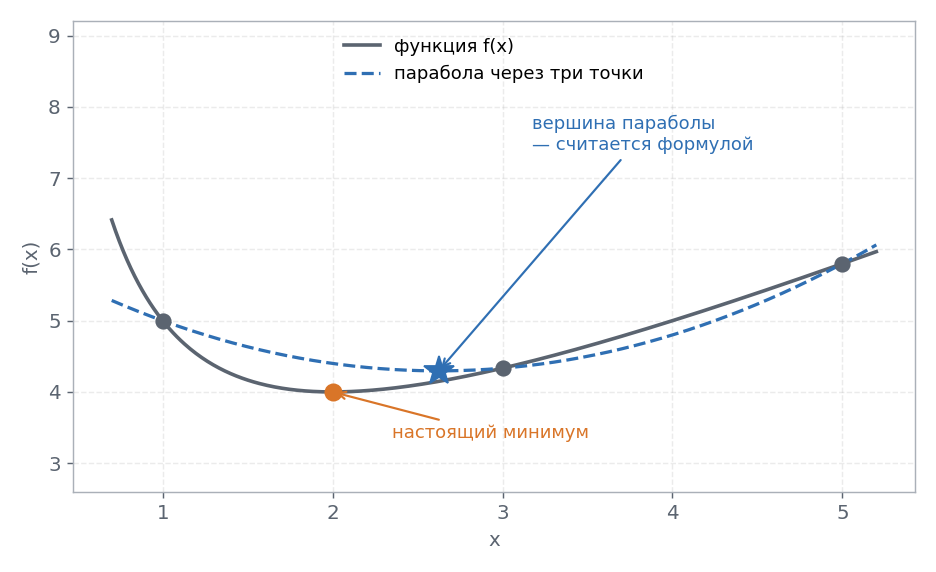

*Одного шага мало — вершина не совпала с минимумом. Но она заметно ближе к нему, чем любая из трёх исходных точек.*

**Задача.** Реализуй метод. Коэффициенты параболы через три точки выведи сам(а) — это система из трёх уравнений. Проверь на двух задачах из списка, сравни с золотым сечением по числу вычислений функции при одинаковой точности.

**Вопросы на понимание метода**

**На какой функции метод даст точный ответ за один шаг?**

Ответ: на квадратичной функции

**Что произойдёт, если три точки окажутся на одной прямой?**

Ответ: у прямой нет вершины, поэтому парабола вырождается (A = 0), метод возвращает точку с флагом False

In [47]:
#2. Фермер огораживает прямоугольный загон у прямой реки — со стороны реки
#забор не нужен. Имеется 200 м сетки. Какие размеры загона дадут наибольшую площадь?

def lenght(x):
    return - (200 * x - 2 * x ** 2)

#Магазин продаёт 4800 единиц товара в год. Каждая поставка обходится в
# 600 руб. независимо от объёма, а хранение единицы на складе — 3 руб./год.
# Какой размер одной партии минимизирует суммарные годовые затраты на заказы и хранение 

def logistic(q):
    return 2880000 / q + 1.5 * q

def evaluation():
    print("=" * 25, "Решение задачи 2", "=" * 25)
    x_opt, f_opt, iterations, func_calls = golden_section(lenght, 0.0, 100.0, eps=1e-3, max_iter=100) 

    print(f"Golden section")
    print("=" * 30)
    y = 200 - 2 * x_opt  # x - ширина загона, y - длина
    print(f"Оптимальная длина загона: {y:.2f} м.")
    print(f"Оптимальная ширина загона: {x_opt:.2f} м.")
    print(f"Количество итераций: {iterations}\nКоличество вызовов функции: {func_calls}")
    print()

    x2, f2, iterations, success, func_calls = parabolic(lenght, 0.0, 100.0, eps=1e-3, max_iter=100)
    print(f"Parabolic")
    print("=" * 30)
    y = 200 - 2 * x2  # x - ширина загона, y - длина
    print(f"Оптимальная длина загона: {y:.2f} м.")
    print(f"Оптимальная ширина загона: {x2:.2f} м.")
    print(f"Количество вызова функции: {func_calls}")
    print()

    print("=" * 25, "Решение задачи 5", "=" * 25)
    x_opt, f_opt, iterations, func_calls = golden_section(logistic, 100, 2000, eps=1e-3, max_iter=100)     
    print(f"Golden section")
    print("=" * 30)
    print(f"Затраты: {f_opt:.2f} руб.")
    print(f"Оптимальный размер партии: {x_opt:.2f} ед / раз. ")   
    print(f"Количество итераций: {iterations}\nКоличество вызовов функции: {func_calls}")
    print()

    x2, f2, iterations, success, func_calls = parabolic(logistic, 100, 2000, eps=1e-3, max_iter=100)
    print(f"Parabolic")
    print("=" * 30)
    print(f"Затраты: {f2:.2f} руб.")
    print(f"Оптимальный размер партии: {x2:.2f} ед / раз. ") 
    print(f"Количество вызова функции: {func_calls}")


if __name__ == "__main__":
    evaluation()


========================= Решение задачи 2 =========================
Golden section
Оптимальная длина загона: 100.00 м.
Оптимальная ширина загона: 50.00 м.
Количество итераций: 25
Количество вызовов функции: 27

Parabolic
Оптимальная длина загона: 100.00 м.
Оптимальная ширина загона: 50.00 м.
Количество вызова функции: 4

========================= Решение задачи 5 =========================
Golden section
Затраты: 4156.92 руб.
Оптимальный размер партии: 1385.64 ед / раз. 
Количество итераций: 32
Количество вызовов функции: 34

Parabolic
Затраты: 4156.92 руб.
Оптимальный размер партии: 1385.64 ед / раз. 
Количество вызова функции: 11


---

## 3. А что если знать о функции больше?

Парабола по трём точкам — догадка о форме, собранная из трёх замеров. Но замеры не единственное, что можно знать о функции. Сравни, чем располагает метод в каждом из трёх случаев:

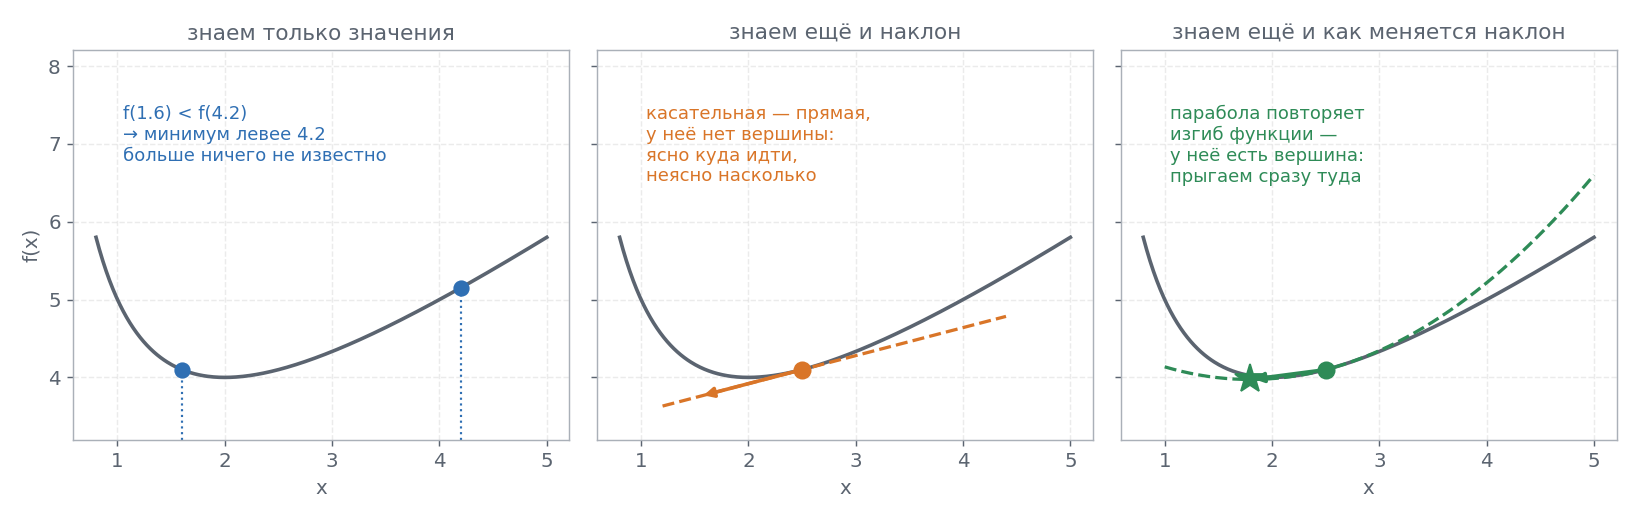

**Слева** — всё, что есть у золотого сечения: два значения и знание, какое меньше. Этого хватает, чтобы отбросить часть отрезка, и не хватает больше ни на что. Отсюда и скорость: каждый шаг сокращает отрезок примерно в 1,6 раза, независимо от того, какая перед нами функция.

**В середине** — известен наклон f′(x). Через точку проходит касательная, и сразу ясно, в какую сторону функция убывает. Но у прямой нет вершины: касательная говорит, *куда* идти, и молчит о том, *насколько далеко*.

**Справа** — известна ещё и вторая производная f″(x): производная от первой, то есть скорость, с которой меняется сам наклон. Прямая для этого уже не годится — у неё наклон всюду одинаковый. Нужна кривая, у которой наклон меняется, и простейшая такая кривая — парабола.

Какую именно параболу взять? У неё три коэффициента, значит подогнать её можно под три условия. В прошлом разделе условиями были три точки, через которые парабола проходит. Здесь условия другие, но их тоже три:

- проходит через нашу точку;
- имеет в ней такой же наклон, как функция;
- наклон у неё меняется с той же скоростью.

Запиши параболу в виде y = a·(x − x₀)² + b·(x − x₀) + c и найди a, b и c из этих трёх условий — выкладка на три строчки.

Дальше остаётся найти вершину параболы по школьной формуле: это и будет следующая точка.

$$x_{new} = x - \frac{f'(x)}{f''(x)}$$

Круто изогнутая парабола — короткий шаг, пологая — длинный. Метод сам подбирает длину шага по форме функции. Это метод Ньютона.

**Задача.** Первые производные у тебя уже выписаны — по ним ты искала корни. Вторые нужно посчитать: продифференцируй f′(x) ещё раз. Сделай это для трёх задач, затем реализуй метод и сравни число итераций с золотым сечением.

### Где у метода границы

Чем сильнее предположение о функции, тем быстрее метод — и тем хуже он себя ведёт там, где предположение не выполняется. Парабола, построенная по первой и второй производным, описывает функцию только вблизи точки. Дальше она может не иметь с ней ничего общего:

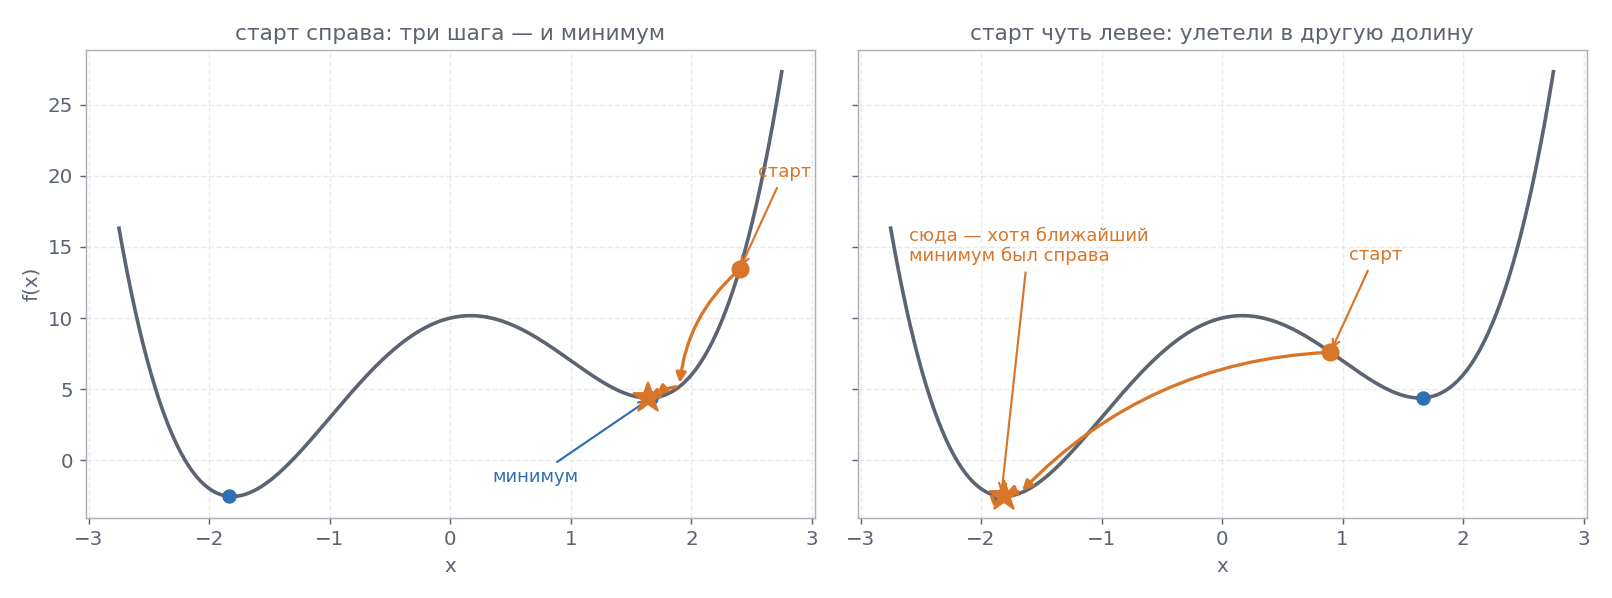

*Одна и та же функция f(x) = x⁴ − 6x² + 2x + 10, один и тот же метод, разные стартовые точки. Слева три шага приводят в минимум. Справа старт сместили влево — и первый же шаг перебросил метод через горку в совсем другую долину.*

**Задача.** Воспроизведи оба случая и построй такую же картинку сама. Найди границу: при каком стартовом значении поведение метода меняется.

In [48]:
def f(x0):
    return x0 ** 4 - 6 * x0 ** 2 + 2 * x0 + 10

def f1(x0):
    return 4 * x0 ** 3 - 12 * x0 + 2

def f2(x0):
    return 12 * x0 ** 2 - 12

#начальные точки(х0)
points = [0, -2, 2, -1.1, -0.9, 1.1, 0.9]

for point in points:
    x0, f1_x0, _, _, ok = newton(f1, f2, point, eps=1e-3, max_iter=100)
    value = f(x0)
    print(f"Точка: {point}")
    print(f"x0: {x0:.4f}")
    print(f"Значение функции в x0: {value:.4f}")
    x0_f2 = f2(x0)

    if not ok:
        print("Метод не сошелся")

    if x0_f2 > 0:
        means = "Min"
    elif x0_f2 < 0:
        means = "Max"
    else:
        means = "Не определено"
    print(means)
    print("=" * 50)

Точка: 0
x0: 0.1683
Значение функции в x0: 10.1675
Max
Точка: -2
x0: -1.8100
Значение функции в x0: -2.5438
Min
Точка: 2
x0: 1.6418
Значение функции в x0: 4.3763
Min
Точка: -1.1
x0: -1.8100
Значение функции в x0: -2.5438
Min
Точка: -0.9
x0: 1.6418
Значение функции в x0: 4.3763
Min
Точка: 1.1
x0: 1.6418
Значение функции в x0: 4.3763
Min
Точка: 0.9
x0: -1.8100
Значение функции в x0: -2.5438
Min


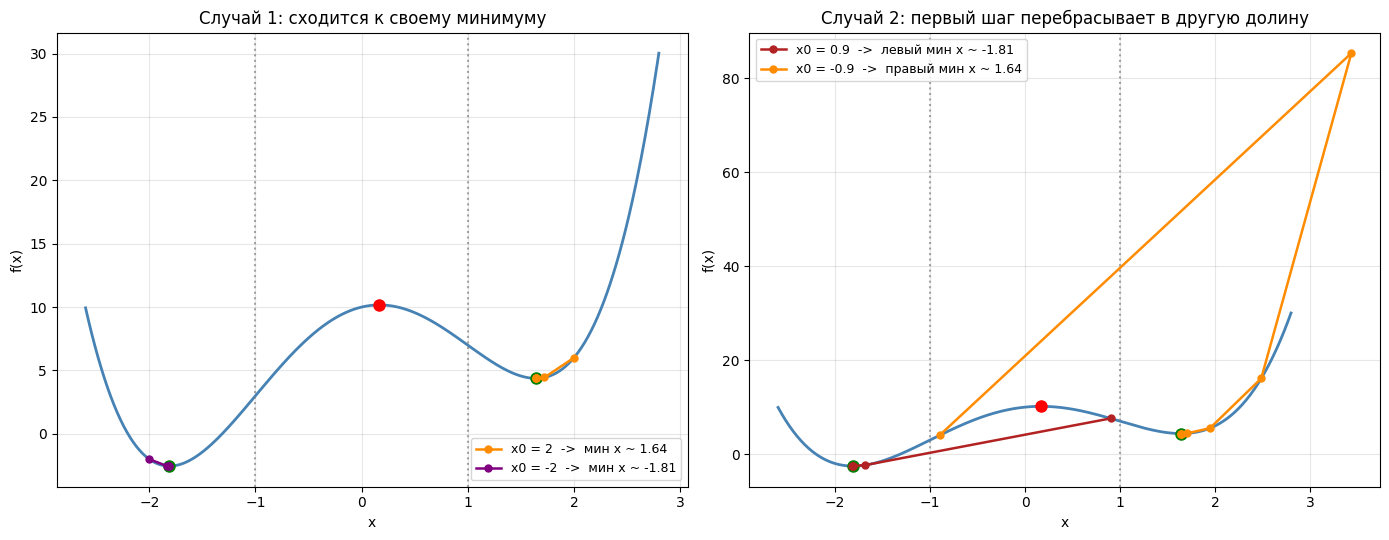

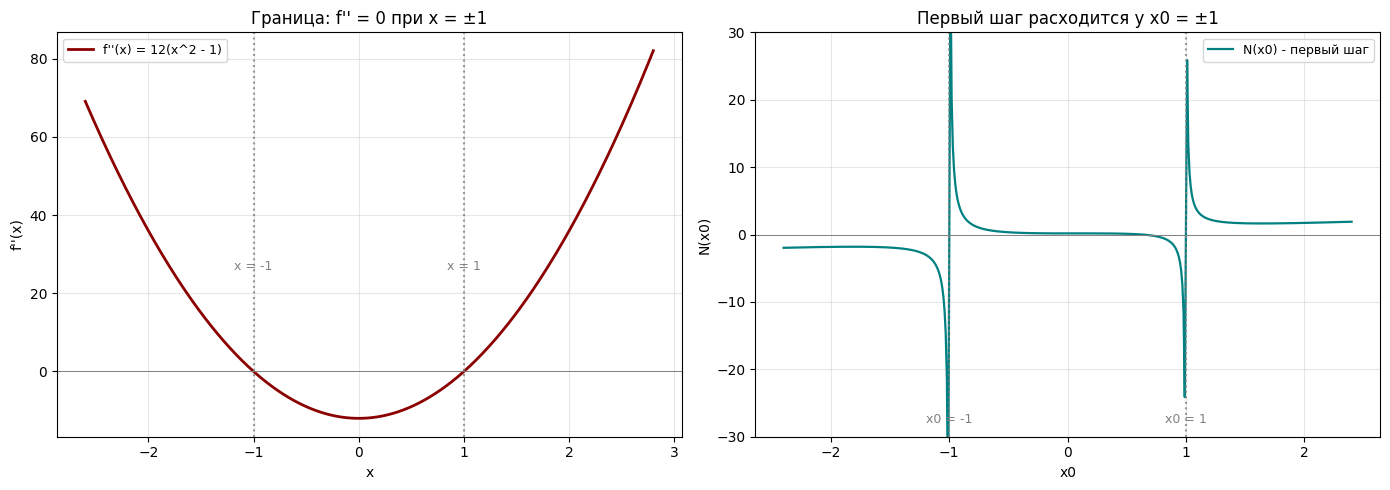

In [49]:
import matplotlib.pyplot as plt

# Ньютон с сохранением всех точек пути: возвращает [x0, x1, x2, ...]
def newton_path(f1, f2, x0, eps=1e-3, max_iter=20):
    path = [x0]
    x = x0
    for _ in range(max_iter):
        if abs(f2(x)) < 1e-12:      # защита от деления на ноль
            break
        x = x - f1(x) / f2(x)       # формула Ньютона
        path.append(x)
        if abs(x - path[-2]) < eps: # шаг меньше eps - сошлись
            break
    return path

# координаты кривой f(x) для графика: от -2.6 до 2.8
xs = [i / 100 for i in range(-260, 281)]
ys = [f(t) for t in xs]

# стационарные точки (f'=0) и их тип по знаку f''
stat = [(-1.81, "мин"), (0.168, "макс"), (1.642, "мин")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax in axes:
    ax.plot(xs, ys, color="steelblue", linewidth=2)
    for x_st, kind in stat:
        color = "green" if kind == "мин" else "red"
        ax.plot(x_st, f(x_st), "o", color=color, markersize=8)
    ax.axvline(-1, color="gray", linestyle=":", alpha=0.7)
    ax.axvline(1, color="gray", linestyle=":", alpha=0.7)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(alpha=0.3)

def draw_path(ax, x0, color, label):
    path = newton_path(f1, f2, x0)
    ax.plot(path, [f(x) for x in path], "o-", color=color,
            linewidth=1.8, markersize=5, label=label)

# слева: старт далеко от горки - сходится к ближнему минимуму
draw_path(axes[0], 2.0, "darkorange", "x0 = 2  ->  мин x ~ 1.64")
draw_path(axes[0], -2.0, "purple", "x0 = -2  ->  мин x ~ -1.81")
axes[0].set_title("Случай 1: сходится к своему минимуму")
axes[0].legend(fontsize=9)

# справа: старт внутри (-1, 1) - первый шаг перебрасывает в другую долину
draw_path(axes[1], 0.9, "firebrick", "x0 = 0.9  ->  левый мин x ~ -1.81")
draw_path(axes[1], -0.9, "darkorange", "x0 = -0.9  ->  правый мин x ~ 1.64")
axes[1].set_title("Случай 2: первый шаг перебрасывает в другую долину")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Граница: f''(x) меняет знак при x = ±1 - там первый шаг Ньютона раздувается
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# слева: f''(x) = 12(x^2 - 1), ноль при x = ±1
ax = axes[0]
ax.plot(xs, [f2(t) for t in xs], color="darkred", linewidth=2, label="f''(x) = 12(x^2 - 1)")
ax.axhline(0, color="gray", linewidth=0.7)
for b in (-1, 1):
    ax.axvline(b, color="gray", linestyle=":", alpha=0.8)
    ax.text(b, 26, f"x = {b}", ha="center", fontsize=9, color="gray")
ax.set_xlabel("x")
ax.set_ylabel("f''(x)")
ax.set_title("Граница: f'' = 0 при x = ±1")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# справа: первый шаг Ньютона N(x0) = x0 - f'(x0)/f''(x0)
ax = axes[1]
xN = []
N = []
for t in [i / 100 for i in range(-240, 241)]:
    if abs(f2(t)) > 1e-9:       # не делим на (почти) ноль
        xN.append(t)
        N.append(t - f1(t) / f2(t))
ax.plot(xN, N, color="teal", linewidth=1.6, label="N(x0) - первый шаг")
ax.axhline(0, color="gray", linewidth=0.7)
for b in (-1, 1):
    ax.axvline(b, color="gray", linestyle=":", alpha=0.8)
    ax.text(b, -28, f"x0 = {b}", ha="center", fontsize=9, color="gray")
ax.set_ylim(-30, 30)
ax.set_xlabel("x0")
ax.set_ylabel("N(x0)")
ax.set_title("Первый шаг расходится у x0 = ±1")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

метод  из точки внутри −1,1 сходится в максимум. из точек - 0.9 ; 0.9 первый же шаг оказывается настолько огромным, что перебрасывает точку в противоположную "долину"

**Что происходит с f″(x) при переходе через эту границу?**

Ответ: при переходе f'' меняет знак. Ньютон при x0=0 сошёлся в максимум, слудовательно тип экстремума нужно проверять отдельно по знаку f''. метод  из точки внутри −1,1 сходится в максимум. из точек - 0.9 ; 0.9 первый же шаг оказывается настолько огромным, что перебрасывает точку в противоположную "долину"

---

## 4. Тот же метод, но без формул производных

Функция может быть задана таблицей измерений или чужой программой — формулы для производной нет и взять её неоткуда. Тогда производную считают приближённо, прямо по значениям функции.

### Откуда берётся формула для первой производной

Производная по определению — предел наклона секущей:

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

Если h не устремлять к нулю, а просто взять небольшим, получится приближение: наклон секущей вместо наклона касательной. Соседнюю точку можно взять справа, а можно слева — разностей получается две.

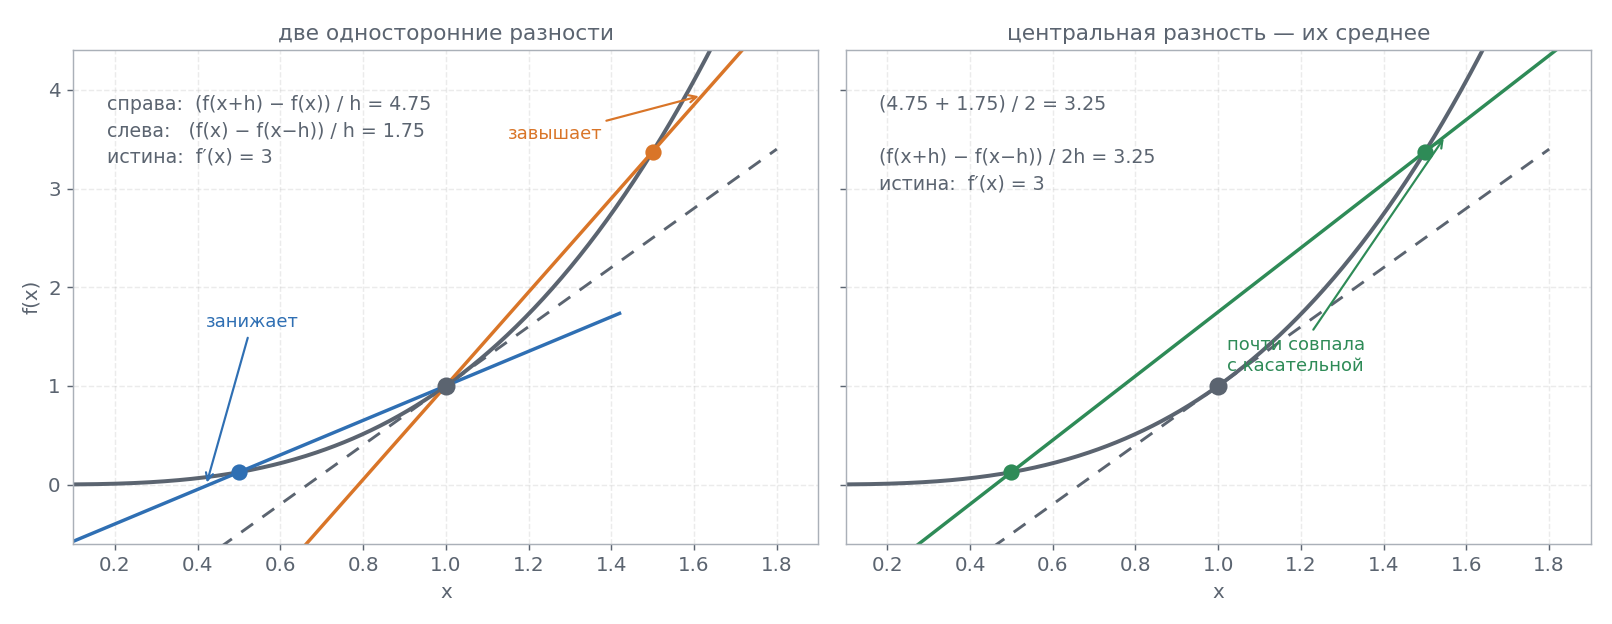

*f(x) = x³, точка x = 1, шаг h = 0,5. Пунктиром — настоящая касательная, её наклон 3.*

Для этой функции секущая справа наклон завышает, слева — занижает. Напрашивается взять их среднее:

$$\frac{1}{2}\left[\frac{f(x+h) - f(x)}{h} + \frac{f(x) - f(x-h)}{h}\right] = \frac{f(x+h) - f(x-h)}{2h}$$

Это центральная разность. Геометрически — наклон секущей через две симметричные точки, мимо самой x. На картинке справа видно, насколько она ближе к касательной, чем любая из односторонних.

### Откуда берётся формула для второй производной

Вторая производная — скорость, с которой меняется наклон. А наклонов у нас как раз два: слева от точки и справа.

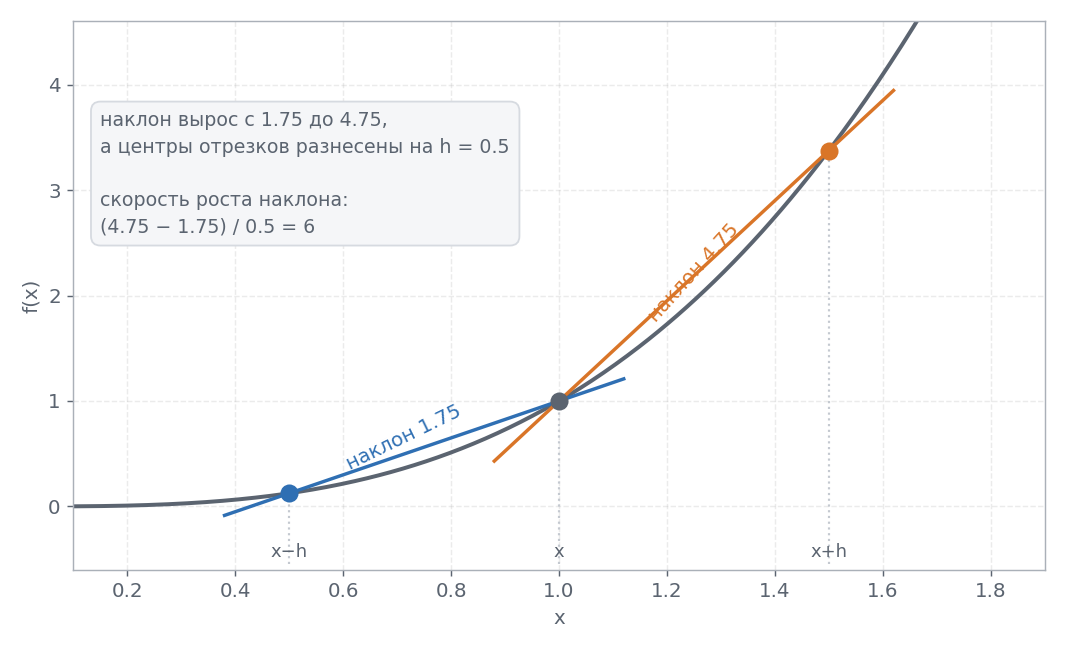

Остаётся поделить разность этих наклонов на расстояние между ними:

$$f''(x) \approx \frac{1}{h}\left[\frac{f(x+h) - f(x)}{h} - \frac{f(x) - f(x-h)}{h}\right] = \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}$$

Проверь оба вывода руками на числах с картинок — они подобраны так, что всё сходится без округлений.

**Задача 4.1.** Возьми функцию, производную которой знаешь точно, и посмотри, как ведёт себя ошибка при уменьшении h вдвое: отдельно у односторонней разности, отдельно у центральной. Во сколько раз падает ошибка в каждом случае?

In [50]:
def f(x):
    return 2 * x ** 3

def f1(x):
    return 6 * x ** 2

h_list = [0.1, 0.05]
x = 1
analit_values = f1(x)

print(f"Точное значение производной в точке {x}: {analit_values}")

errors1 = []
errors2 = []

for h in h_list:
    # Односторонняя разность
    d1_num1 = (f(x + h) - f(x)) / h 
    
    # Центральная разность
    d1_num2 = (f(x + h) - f(x - h)) / (2 * h) 
    
    # Относительная ошибка 
    error1 = abs(d1_num1 - analit_values) / analit_values * 100
    errors1.append(error1)
    error2 = abs(d1_num2 - analit_values) / analit_values * 100
    errors2.append(error2)
    
    print(f"h: {h:<5} | односторонняя: {d1_num1:<8.4f} (ошибка: {error1:.2f}%) | центральная: {d1_num2:<8.4f} (ошибка: {error2:.4f}%)")

    # Считаем во сколько раз упала ошибка при уменьшении h в 2 раза
ratio1 = errors1[0] / errors1[1]
ratio2 = errors2[0] / errors2[1]

print(f"\nОдносторонняя: ошибка упала в {ratio1:.2f} раз")
print(f"Центральная:   ошибка упала в {ratio2:.2f} раз")


Точное значение производной в точке 1: 6
h: 0.1   | односторонняя: 6.6200   (ошибка: 10.33%) | центральная: 6.0200   (ошибка: 0.3333%)
h: 0.05  | односторонняя: 6.3050   (ошибка: 5.08%) | центральная: 6.0050   (ошибка: 0.0833%)

Односторонняя: ошибка упала в 2.03 раз
Центральная:   ошибка упала в 4.00 раз


**Во сколько раз падает ошибка у каждой формулы и почему они ведут себя по-разному?**

Ответ: В 2.03 раза в случае односторонней разности и в 4.00 в случае центральной. Центральная разность точнее, потому что берет точки с двух сторон, и их ошибки компенсируют друг друга, поэтому ошибка убывает пропорционально h у односторонней разности и пропорционально h**2 у центральной.

**Задача 4.2.** Повтори метод Ньютона на тех же трёх задачах, заменив аналитические производные разностными. Убедись, что ответы совпали.

Построй график ошибки в зависимости от h: 10⁻¹, 10⁻², … 10⁻¹². Найди h, при котором ошибка наименьшая.

In [51]:
tasks = [
    ("Задача 0", 
     lambda x: x / 4.0 + math.sqrt((8.0 - x) ** 2 + 9.0) / 3.0,
     8 - math.sqrt(81 / 7), 4.0),
    ("Задача 5", 
     lambda q: 2880000 / q + 1.5 * q,
     800 * math.sqrt(3), 1500.0),
    ("Задача 9", 
     lambda t: (16 - math.cos(t)) / math.sin(t),
     math.acos(1 / 16), 1.5),
]

def make_numeric_derivs(f, h):
    def d1(x):
        return (f(x + h) - f(x - h)) / (2 * h)
    def d2(x):
        return (f(x + h) - 2 * f(x) + f(x - h)) / (h * h)
    return d1, d2

h_list = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]

results = {}
for name, f, x_star, x0 in tasks:
    print(f"{name}  точный x = {x_star:.4f}")
    errs, oks = [], []
    for h in h_list:
        d1, d2 = make_numeric_derivs(f, h)
        x, _, it, fc, ok = newton(d1, d2, x0, eps=1e-9)
        err = abs(x - x_star)
        errs.append(err)
        oks.append(ok)
        print(f"  h={h:.0e}  x={x:.4f}  ошибка={err:.2e}  сошёлся={ok}")
    
    min_err = min(errs)
    best_h = h_list[errs.index(min_err)]
    if name == "Задача 5":
        print(f"  рабочий диапазон h ≈ 1e-1…1e-4 (при h ≤ 1e-5 — обрыв: f″ = 0), минимум ошибки {min_err:.2e}\n")
    else:
        print(f"  ЛУЧШИЙ h = {best_h:g}   ошибка = {min_err:.2e}\n")
    results[name] = {"h": h_list, "err": errs, "ok": oks, "best_h": best_h, "min_err": min_err}

Задача 0  точный x = 4.5983
  h=1e-01  x=4.5975  ошибка=8.27e-04  сошёлся=True
  h=1e-02  x=4.5983  ошибка=8.27e-06  сошёлся=True
  h=1e-03  x=4.5983  ошибка=8.27e-08  сошёлся=True
  h=1e-04  x=4.5983  ошибка=8.04e-10  сошёлся=True
  h=1e-05  x=4.5983  ошибка=3.14e-10  сошёлся=True
  h=1e-06  x=4.5983  ошибка=7.07e-09  сошёлся=False
  h=1e-07  x=4.1858  ошибка=4.13e-01  сошёлся=False
  h=1e-08  x=3.9791  ошибка=6.19e-01  сошёлся=False
  h=1e-09  x=4.0000  ошибка=5.98e-01  сошёлся=False
  h=1e-10  x=4.0000  ошибка=5.98e-01  сошёлся=False
  h=1e-11  x=4.0000  ошибка=5.98e-01  сошёлся=False
  h=1e-12  x=4.0000  ошибка=5.98e-01  сошёлся=True
  ЛУЧШИЙ h = 1e-05   ошибка = 3.14e-10

Задача 5  точный x = 1385.6406
  h=1e-01  x=1385.6406  ошибка=3.61e-06  сошёлся=True
  h=1e-02  x=1385.6406  ошибка=5.07e-08  сошёлся=True
  h=1e-03  x=1385.6406  ошибка=1.28e-07  сошёлся=True
  h=1e-04  x=1385.6406  ошибка=1.43e-06  сошёлся=True
  h=1e-05  x=1500.0000  ошибка=1.14e+02  сошёлся=False
  h=1e-06  x

**График ошибки от h.** Ошибка метода Ньютона с разностными производными в зависимости от шага h (обе оси логарифмические). Звёздочкой отмечен h, при котором ошибка наименьшая; подпись у звезды — это значение h.

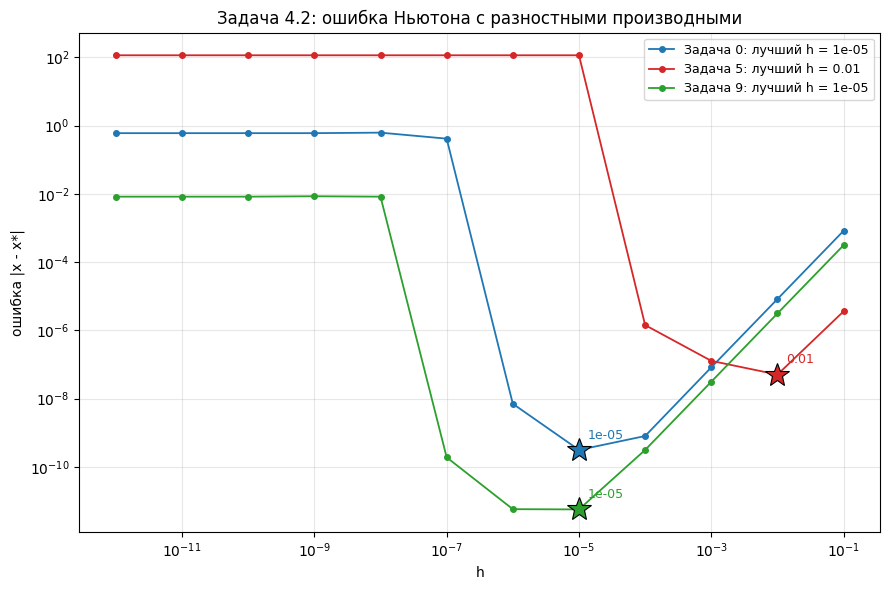

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
colors = {"Задача 0": "#1f77b4", "Задача 5": "#d62728", "Задача 9": "#2ca02c"}

for name, data in results.items():
    col = colors.get(name)
    plt.loglog(data["h"], data["err"], "o-", color=col, ms=4, lw=1.3,
               label=f"{name}: лучший h = {data['best_h']:g}")
    plt.plot(data["best_h"], data["min_err"], marker="*", color=col,
             ms=18, mec="k", mew=0.8, zorder=5)
    plt.annotate(f"{data['best_h']:g}", xy=(data["best_h"], data["min_err"]),
                 xytext=(6, 8), textcoords="offset points", fontsize=9, color=col)

plt.xlabel("h")
plt.ylabel("ошибка |x - x*|")
plt.title("Задача 4.2: ошибка Ньютона с разностными производными")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Почему при дальнейшем уменьшении h ошибка начинает расти?**

Ответ: ошибка начинает расти т.к.при слишком малых h при вычитании большинство значащих цифр сокращаются и остается шум от округления,  усиленный делением на маленькое h. Успех на h = 1e-12 на двух задачах объясняется тем, что шаг оказывается меньше eps, из-за чего срабатывает критерий останова и метод объявляет успех на шуме.

**Где тонет вторая разность.** Числитель `f(x+h) − 2f(x) + f(x−h)` имеет порядок `f″·h²`, а каждое слагаемое известно с ошибкой порядка `ε·|f|`, где `ε ≈ 2.2·10⁻¹⁶`. Разность ещё что-то значит, пока `f″·h² ≫ ε·|f|`. У EOQ `f ≈ 4000`, `f″ ≈ 0.002`, поэтому отношение `f″/|f|` хуже в миллионы раз, чем у задачи 9 (`f ≈ 16`, `f″ ≈ 16`) — порог наступает на четыре порядка раньше. При `h = 10⁻⁴` сигнал/шум ≈ 19, а при `h = 10⁻⁵` численная `f″` становится ровно нулём, срабатывает проверка `hess == 0` в `newton`, и метод возвращает стартовую точку 1500. Это не расходимость, а отказ защиты. Поэтому для EOQ честнее говорить о рабочем диапазоне `h ≈ 10⁻¹…10⁻⁴`, а не о «лучшем» `h`.

In [53]:
# Проверка: на EOQ при h = 1e-5 численная f″ становится ровно нулём,
# и newton отказывается (в нём стоит проверка hess == 0).
f_eoq = lambda q: 2880000 / q + 1.5 * q
for h in (1e-4, 1e-5):
    _, d2 = make_numeric_derivs(f_eoq, h)
    print(f"h = {h:.0e}:  численная f″(1500) = {d2(1500)}")

h = 1e-04:  численная f″(1500) = 0.0017280399333685637
h = 1e-05:  численная f″(1500) = 0.0


---

## 5. Случайный поиск

Самый простой метод из возможных: разбросать по области N случайных точек и взять лучшую из них.

**Задача.** Реализуй. Проверь на задаче с одной переменной и на задаче с двумя.

Затем прикинь на бумаге: сколько точек нужно, чтобы найти минимум с точностью 0,01 по каждой координате, если переменных 1, 2, 3, 5? Проверь расчёт численно для одной и двух.

In [54]:
def road(x):                       
    return x / 4.0 + math.sqrt((8.0 - x) ** 2 + 9.0) / 3.0

def f_point(p):                   
    return road(p[0])

def random_search(f, bounds, n_points, seed=None):
    rng = random.Random(seed)
    best_x, best_f = None, float('inf')
    for _ in range(n_points):
        x = tuple(rng.uniform(lo, hi) for (lo, hi) in bounds)
        val = f(x)
        if val < best_f:
            best_f, best_x = val, x
    return best_x, best_f

best_x, best_f = random_search(f_point, [(0.0, 8.0)], 5000, seed=1)
print(f"x = {best_x[0]:.4f}")      
print(f"f(x) = {best_f:.4f}")


x = 4.5980
f(x) = 2.6614


In [55]:
x_star = 8 - math.sqrt(81 / 7)  # аналитический минимум задачи 0: ≈ 4.5983
L = 8.0

def verify_task0(N, trials=2000, eps=0.01):
    ok = 0
    for seed in range(trials):           # много независимых прогонов
        bx, _ = random_search(f_point, [(0.0, L)], N, seed=seed)
        if abs(bx[0] - x_star) <= eps:   # лучшая точка попала в окно?
            ok += 1
    return ok / trials                   # доля успехов

print(f"p = {2 * 0.01 / L:.4f}  1/p = {1 / (2 * 0.01 / L):.0f}  ln20/p ≈ {math.log(20) / (2 * 0.01 / L):.0f}")
for N in (400, 1200):
    print(f"N = {N}: доля успехов = {verify_task0(N):.3f}")

p = 0.0025  1/p = 400  ln20/p ≈ 1198
N = 400: доля успехов = 0.637
N = 1200: доля успехов = 0.949


In [56]:
def market(x, y):
    return - (40 * x + 50 * y - x ** 2 - y **2 - x * y)

def market_point(p):
    return market(p[0], p[1])

best_x, best_f = random_search(market_point, [(0.0, 20.0), (0.0, 30.0)], 5000, seed=1)
print(f"x1 = {best_x[0]:.4f} | x2 = {best_x[1]:.4f}")
print(f"прибыль = {abs(best_f):.4f}")

x1 = 10.1993 | x2 = 19.7606
прибыль = 699.9507


In [57]:
def verify_market(N, trials=1000, eps=0.01):
    ok = 0
    for seed in range(trials):
        bx, _ = random_search(market_point, [(9.5, 10.5), (19.5, 20.5)], N, seed=seed)
        if abs(bx[0] - 10.0) <= eps and abs(bx[1] - 20.0) <= eps:
            ok += 1
    return ok / trials

for N in (2500, 7500):
    print(f"N = {N}: доля успехов = {verify_market(N):.3f}")

N = 2500: доля успехов = 0.612
N = 7500: доля успехов = 0.924


In [58]:
def verify_market(N, trials=1000, eps=0.01):
    ok_best = 0  # Счётчик 1: лучшая точка попала в окно
    ok_any = 0   # Счётчик 2: хотя бы одна точка из N попала в окно
    
    for seed in range(trials):
        rng = random.Random(seed)
        best_x, best_f = None, float('inf')
        any_in_window = False
        
        # Генерируем N точек и проверяем каждую
        for _ in range(N):
            x = tuple(rng.uniform(lo, hi) for (lo, hi) in [(9.5, 10.5), (19.5, 20.5)])
            val = market_point(x)
            
            # Проверяем попадание текущей точки в eps-окно минимума (10, 20)
            if abs(x[0] - 10.0) <= eps and abs(x[1] - 20.0) <= eps:
                any_in_window = True
                
            # Обновляем лучшую точку (логика обычного random_search)
            if val < best_f:
                best_f, best_x = val, x
        
        # 1. Проверяем, попала ли лучшая точка в окно
        if abs(best_x[0] - 10.0) <= eps and abs(best_x[1] - 20.0) <= eps:
            ok_best += 1
            
        # 2. Проверяем, была ли хоть одна точка в окне
        if any_in_window:
            ok_any += 1
            
    return ok_best / trials, ok_any / trials

# Запуск проверки для двух значений N
for N in (2500, 7500):
    p_best, p_any = verify_market(N)
    print(f"N = {N}: лучшая точка в окне = {p_best:.3f}, хотя бы одна точка в окне = {p_any:.3f}")

N = 2500: лучшая точка в окне = 0.612, хотя бы одна точка в окне = 0.642
N = 7500: лучшая точка в окне = 0.924, хотя бы одна точка в окне = 0.951


У данной функции «долина» вокруг минимума вытянутая (кривизна по диагонали меньше, чем по осям). Из-за этого «лучшая по значению» точка может оказаться чуть дальше от центра, чем требует точность eps, хотя какая-то точка внутри диапазона есть. Поэтому измеренная доля чуть меньше теоретической

Сколько точек нужно чтобы найти минимум с точностью 0.01? если вероятность: (p = (2 * eps) / L) ** d, где L - длина диапазона, d - степень, то количество точек будет N = (L / (2 * eps)) ** d. Из N точек — хотя бы одна с вероятностью 1−(1−p)^N. Отсюда N = ln(1−γ)/ln(1−p): при γ=0.63 получается 1/p = (L/(2δ))ᵈ, при γ=0.95 — ≈3/p.

**Почему здесь L = 1, а не 8.** В задаче «дорога/лес» длина диапазона была L = 8 — это параметр конкретной задачи. Здесь L = 1 взят не для задачи, а как условный масштаб: считаем, сколько точек нужно для точности 0.01 на отрезке единичной длины, и смотрим, как это число растёт с числом переменных (d = 1, 2, 3, 5, 100). Это прикидка роста, а не расчёт для «дороги/леса»: при L = 8 все числа были бы в 8^d раз больше, но качественная картина та же.

In [59]:
eps = 0.01
L = 1 #считаем про длине диапазона 1
d_values = [1, 2, 3, 5]
for d in d_values:
    n = (L / (2 * eps)) ** d
    print(f"d:{d}| 63% успеха: {n:<12} | 95% успеха: {n * 3:<12}")

d:1| 63% успеха: 50.0         | 95% успеха: 150.0       
d:2| 63% успеха: 2500.0       | 95% успеха: 7500.0      
d:3| 63% успеха: 125000.0     | 95% успеха: 375000.0    
d:5| 63% успеха: 312500000.0  | 95% успеха: 937500000.0 


**Сколько точек потребуется для функции от 100 переменных и сколько времени это займёт, если компьютер вычисляет миллион значений в секунду?**

100 переменных, L=1, eps=0.01

63% успеха: 7.89e+169 точек | Время: 2.50e+156 лет

95% успеха: 2.37e+170 точек | Время: 7.50e+156 лет

**Тот же вопрос про перебор по сетке: сколько узлов будет у сетки из 100 точек по каждой из 100 координат?**

Ответ: 10 ** 200, таким образом можно сделать вывод, что перебор по сетке становится дорогостоящим в плане вычислений при увеличении количества координат, что делает его неприменимым методом для маштабных задач. 

Итог: сетка и случайный поиск умирают при росте размерности, остаётся идти по направлению — градиенту

In [60]:
eps = 0.01
L = 1 #считаем про длине диапазона 1
d_values = [100]
speed_sec = 10 ** 6 #миллион в секунду
speed_hour = speed_sec * 3600
speed_year = speed_hour * 24 * 365
for d in d_values:
    n_63 = (L / (2 * eps)) ** d
    n_95 = 3 * n_63
    print(f"100 переменных, L=1, eps=0.01")
    print(f"63% успеха: {n_63:.2e} точек | Время: {n_63 / speed_year:.2e} лет")
    print(f"95% успеха: {n_95:.2e} точек | Время: {n_95 / speed_year:.2e} лет")

100 переменных, L=1, eps=0.01
63% успеха: 7.89e+169 точек | Время: 2.50e+156 лет
95% успеха: 2.37e+170 точек | Время: 7.50e+156 лет
